In [21]:
import matplotlib.pyplot as plt
import numpy as np
import os, json
import pandas as pd
import seaborn as sns
import json

# Load json files

In [31]:
def json_to_df(path_to_json):
    # Source - https://stackoverflow.com/a
    # Posted by Scott, modified by community. See post 'Timeline' for change history
    # Retrieved 2026-01-26, License - CC BY-SA 3.0
    
    json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]
    df_list = []
    for f in json_files:
        with open(path_to_json+f) as json_data:
            data = json.load(json_data)
            json_data.close()
    
        hyperparams = ['D', 'N', 'K', 'n_clients', 'lambda', 'lr', 
                       'seed', 'alpha', 'runtime_sec', 'shift_scale']
        ll = ['ll_c', 'll_l', 'fl_ll']
        results = {k: v for k, v in data.items() if k not in hyperparams}

        rows = []
        rows.append({
            **{k: data[k] for k in hyperparams & data.keys()},
            'algorithm': 'central',
            'Log-likelihood': results['ll_c'],
            'err_true': results['centralized_vs_true'],
            'err_central': None
        })
        rows.append({
            **{k: data[k] for k in hyperparams & data.keys()},
            'algorithm': 'local',
            'Log-likelihood': results['ll_l'],
            'err_true': results['local_vs_true'],
            'err_central': results['local_vs_central']
        })
        rows.append({
            **{k: data[k] for k in hyperparams & data.keys()},
            'algorithm': 'fl',
            'Log-likelihood': results['fl_ll'],
            'err_true': results['fl_vs_true'],
            'err_central': results['fl_vs_central']
        })
        rows.append({
            **{k: data[k] for k in hyperparams & data.keys()},
            'algorithm': 'fl_aug',
            'Log-likelihood': results['fl_aug_ll'],
            'err_true': results['fl_vs_true_aug'],
            'err_central': results['fl_vs_central_aug']
        })
        df_list.append(pd.DataFrame(rows))
    return pd.concat(df_list, ignore_index=True)

In [39]:
df_iid = json_to_df('../results/results_iid/')
df_lskew = json_to_df('../results/results_dirichlet/')
df_shift = json_to_df('../results/results_means_shift/')
df_cluster_drop = json_to_df('../results/results_cluster_drop/')

In [32]:
def json_to_df(path_to_json):
    # Source - https://stackoverflow.com/a
    # Posted by Scott, modified by community. See post 'Timeline' for change history
    # Retrieved 2026-01-26, License - CC BY-SA 3.0
    
    json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]
    df_list = []
    for f in json_files:
        with open(path_to_json+f) as json_data:
            data = json.load(json_data)
            json_data.close()
    
        hyperparams = ['D', 'N', 'K', 'n_clients', 'lambda', 'lr', 
                       'seed', 'alpha', 'runtime_sec', 'shift_scale']
        ll = ['ll_c', 'll_l', 'fl_ll']
        results = {k: v for k, v in data.items() if k not in hyperparams}

        rows = []
        rows.append({
            **{k: data[k] for k in hyperparams & data.keys()},
            'algorithm': 'central',
            'Log-likelihood': results['ll_c'],
            'NMI': results['centralized_nmi'],
            'AMI': results['centralized_ami']
        })
        rows.append({
            **{k: data[k] for k in hyperparams & data.keys()},
            'algorithm': 'local',
            'Log-likelihood': results['ll_l'],
            'NMI': results['local_nmi'],
            'AMI': results['local_ami']
        })
        rows.append({
            **{k: data[k] for k in hyperparams & data.keys()},
            'algorithm': 'fl',
            'Log-likelihood': results['fl_ll'],
            'NMI': results['fl_nmi'],
            'AMI': results['fl_ami']
        })
        rows.append({
            **{k: data[k] for k in hyperparams & data.keys()},
            'algorithm': 'fl_aug',
            'Log-likelihood': results['fl_aug_ll'],
            'NMI': results['fl_aug_nmi'],
            'AMI': results['fl_aug_ami']
        })
        df_list.append(pd.DataFrame(rows))
    return pd.concat(df_list, ignore_index=True)

In [33]:
df_mnist = json_to_df('results_mnist/')

In [19]:
df_plot = df_iid[ (df_iid["D"]==10) & (df_iid["algorithm"]!='fl_aug')]
df_plot.to_csv('df_iid.csv')

In [36]:
df_plot = df_shift[ (df_shift["D"]==10) & (df_shift["algorithm"]!='fl_aug')]
df_plot.to_csv('df_shift.csv')

In [39]:
df_plot = df_cluster_drop[ (df_cluster_drop["D"]==10) & (df_cluster_drop["algorithm"]!='fl_aug')]
df_plot.to_csv('df_cluster_drop.csv')

In [38]:
df_plot = df_mnist[ (df_mnist["D"]==10) & (df_mnist["algorithm"]!='fl_aug') & (df_mnist["N"]!=30)]
df_plot.to_csv('df_mnist.csv')

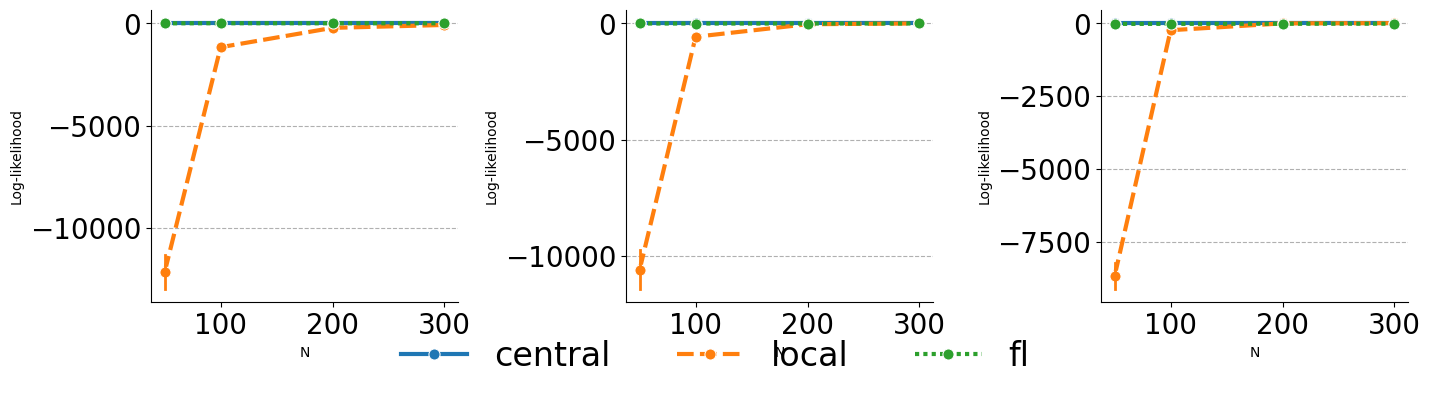

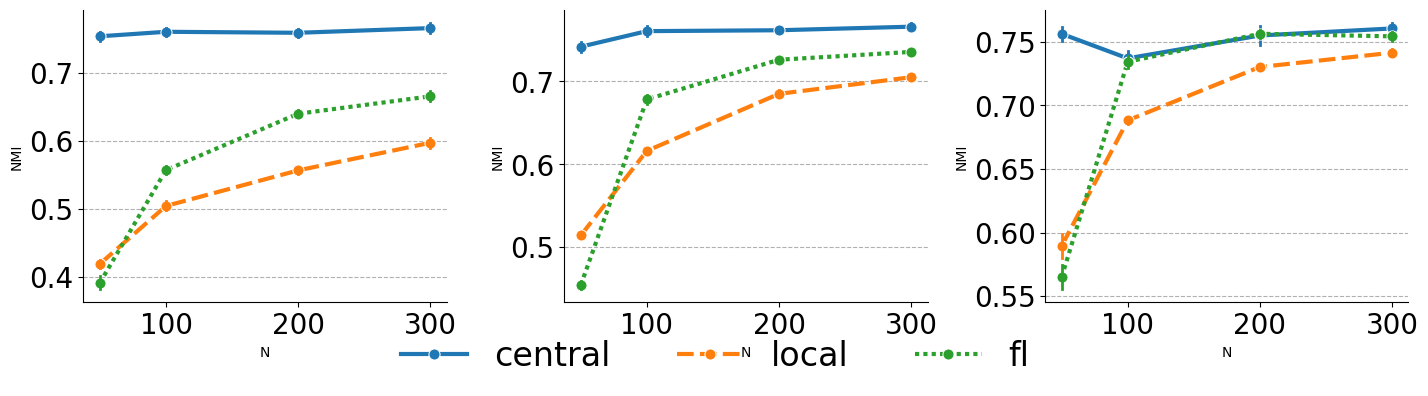

In [46]:
plot_metrics(df_plot, "N", "Log-likelihood", "alpha")
plot_metrics(df_plot, "N", "NMI", "alpha")

# IID SPLIT

In [40]:
df_lambda_0 = df_iid[ (df_iid["lambda"]==0)]
df_lambda_05 = df_iid[ (df_iid["lambda"]==0.5)]
df_lambda_1 = df_iid[ (df_iid["lambda"]==1)]

In [41]:
def plot_metrics(
    df,
    x_label,
    metrics,
    col,
    height=4,
    aspect=1.2,
    sharey=False, # can use 'row'
    yscale = 'linear', # "linear", "log",
):
    unique_cols = sorted(df[col].unique())
    fig, axes = plt.subplots(
        1, len(unique_cols),
        figsize=(len(unique_cols) * aspect * height, height),
        sharex=True,
        sharey=sharey
    )

    for j, c_val in enumerate(unique_cols):
        ax = axes[j]
        subset = df[df[col] == c_val]

        sns.lineplot(
            data=subset,
            x=x_label,
            y=metrics,
            hue="algorithm",
            style="algorithm",
            marker="o",
            markersize=8,
            err_style="bars",
            errorbar=("se", 1),
            err_kws={"linewidth": 2},
            linewidth=3,
            ax=ax
        )

        ax.tick_params(axis='both', which='major', labelsize=20) 
        ax.grid(True, axis="y", linestyle="--")
        ax.grid(False, axis="x")
        ax.spines[['right', 'top']].set_visible(False)

        # Remove individual legends
        ax.get_legend().remove() if ax.get_legend() else None

    # Add one shared legend at the bottom
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="lower center", ncol=len(set(labels)),
        frameon=False, fontsize=24, bbox_to_anchor=(0.5, -0.02)
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for shared legend
    plt.show()



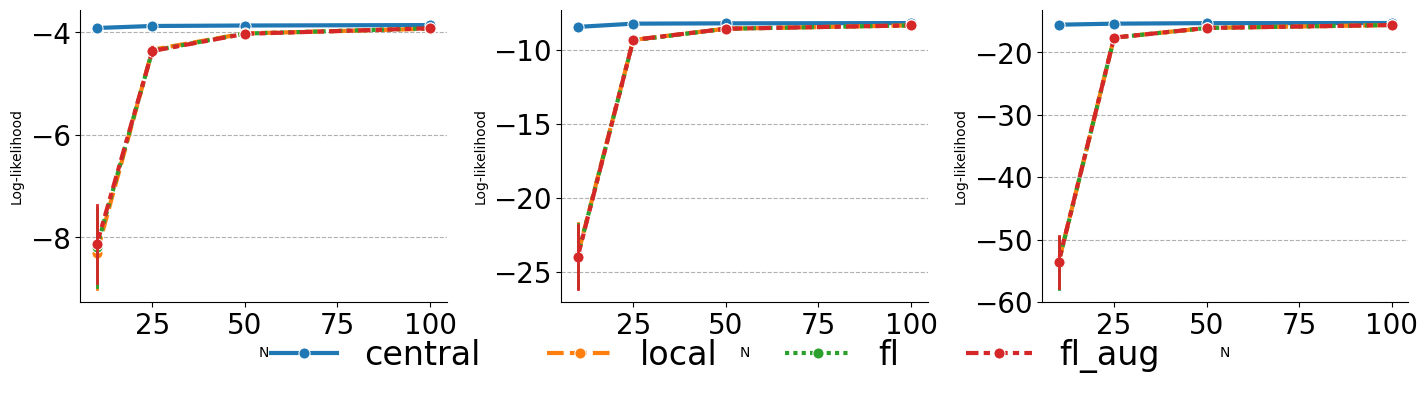

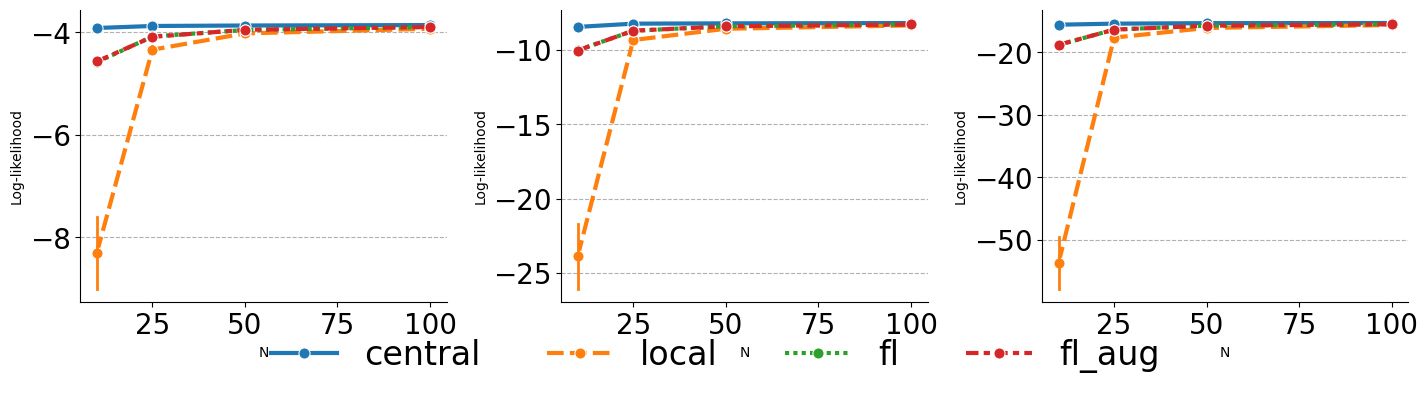

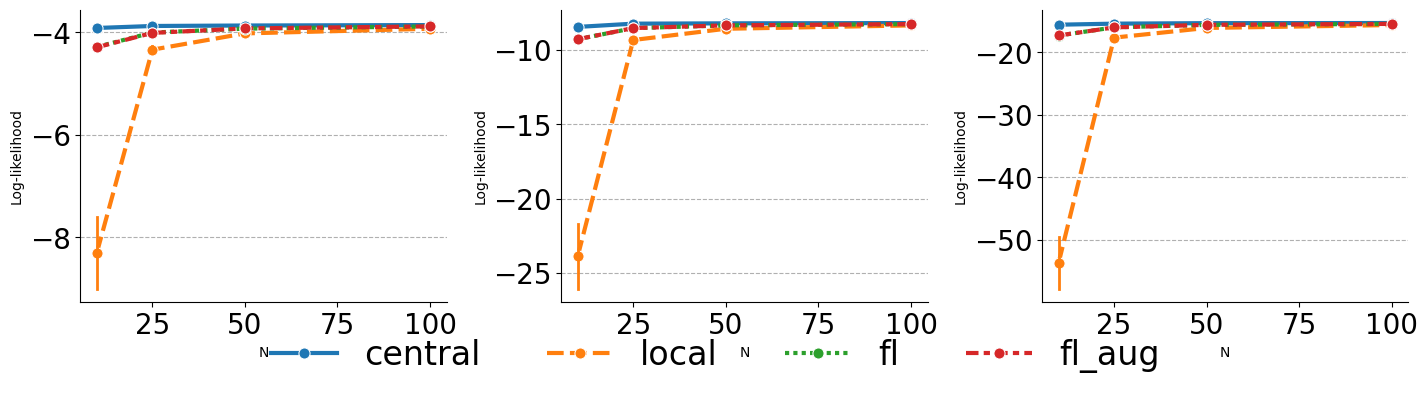

In [42]:
plot_metrics(df_lambda_0, "N", "Log-likelihood", "D")
plot_metrics(df_lambda_05, "N", "Log-likelihood", "D")
plot_metrics(df_lambda_1, "N", "Log-likelihood", "D")

In [13]:
def plot_metrics(
    df,
    x_label,
    metrics,
    col,
    height=4,
    aspect=1.2,
    sharey=True,      # can also be 'row'
    yscale="linear",   # "linear" or "log"
):
    unique_vals = sorted(df[col].unique())

    fig, axes = plt.subplots(
        1,
        len(unique_vals),
        figsize=(len(unique_vals) * aspect * height, height),
        sharex=True,
        sharey=sharey,
    )

    # Ensure axes is always iterable
    if len(unique_vals) == 1:
        axes = [axes]

    for ax, val in zip(axes, unique_vals):
        subset = df[df[col] == val]

        sns.lineplot(
            data=subset,
            x=x_label,
            y=metrics,
            hue="algorithm",
            style="algorithm",
            marker="o",
            markersize=8,
            linewidth=3,
            err_style="bars",
            errorbar=("se", 1),
            err_kws={"linewidth": 2},
            ax=ax,
        )

        ax.set_title(str(val), fontsize=22)
        ax.set_yscale(yscale)

        ax.tick_params(axis="both", which="major", labelsize=20)
        ax.grid(True, axis="y", linestyle="--", alpha=0.7)
        ax.grid(False, axis="x")
        ax.spines[["top", "right"]].set_visible(False)

        # Remove per-axis legends
        legend = ax.get_legend()
        if legend:
            legend.remove()

    # Shared legend
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(set(labels)),
        frameon=False,
        fontsize=24,
        bbox_to_anchor=(0.5, -0.02),
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


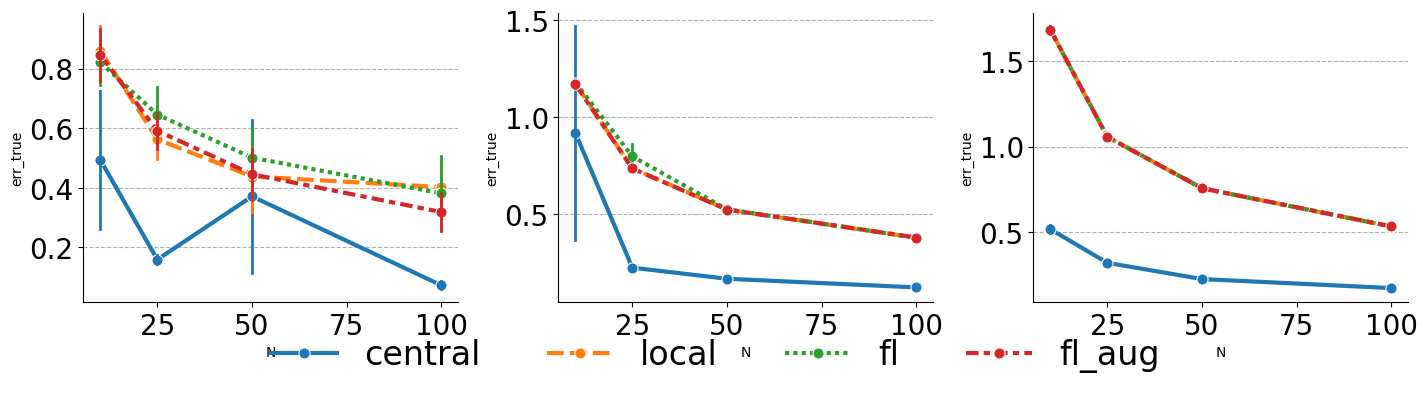

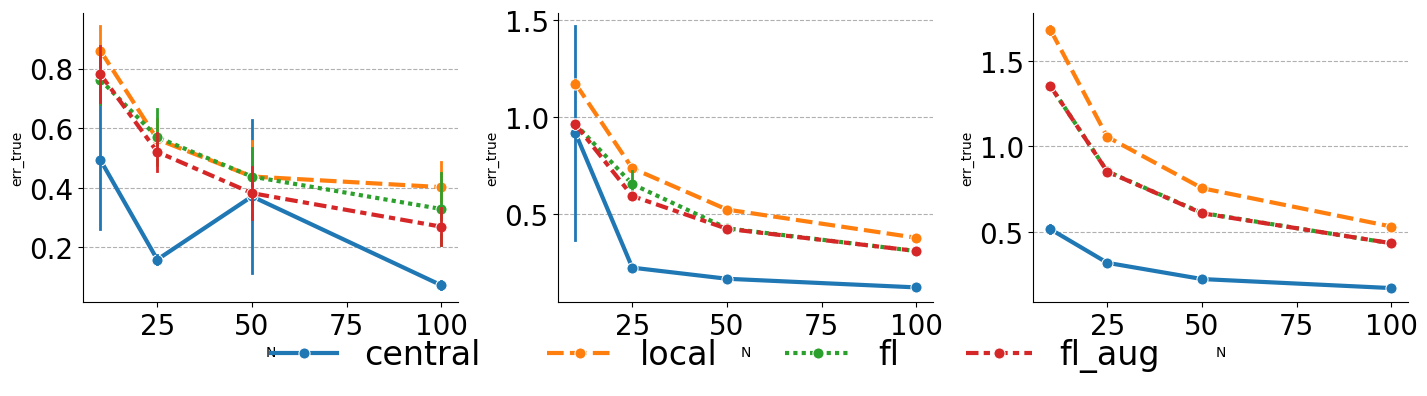

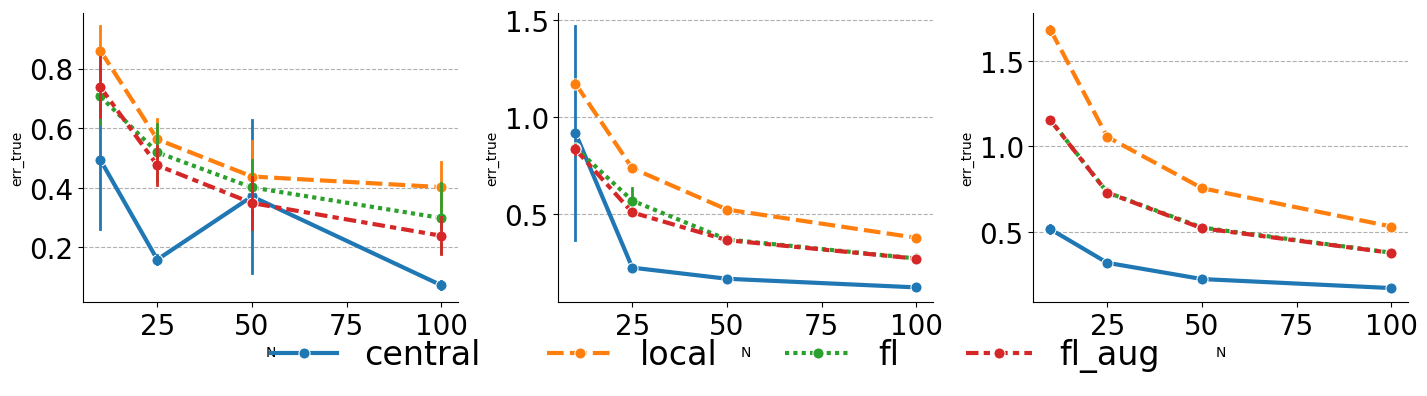

In [43]:
plot_metrics(df_lambda_0, "N", "err_true", "D")
plot_metrics(df_lambda_05, "N", "err_true", "D")
plot_metrics(df_lambda_1, "N", "err_true", "D")

# Label SKEW

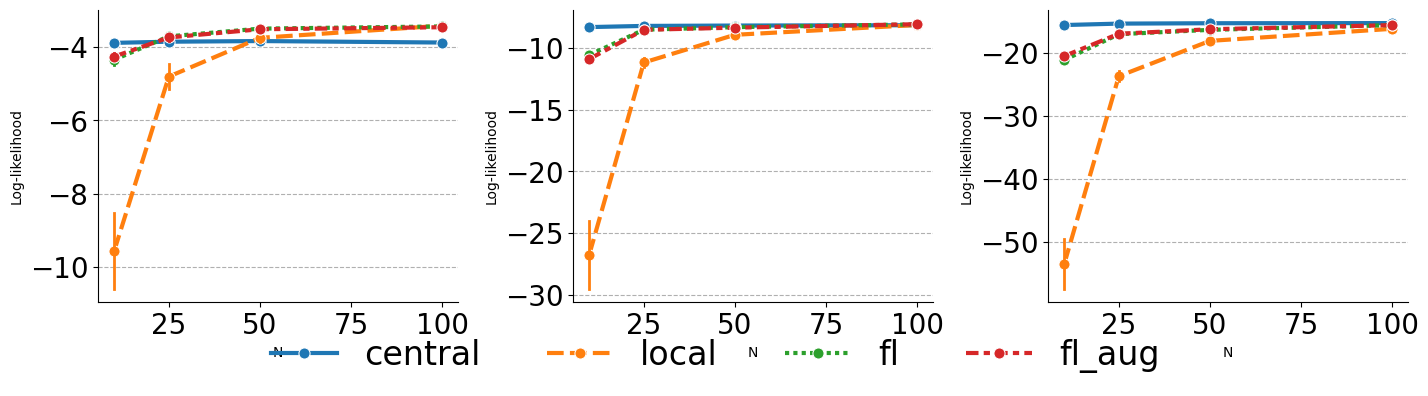

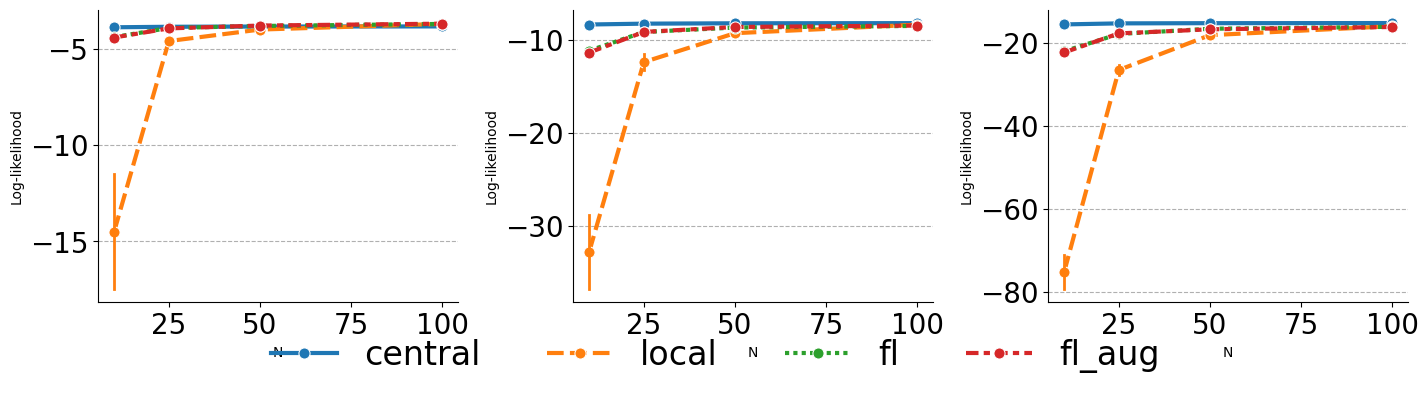

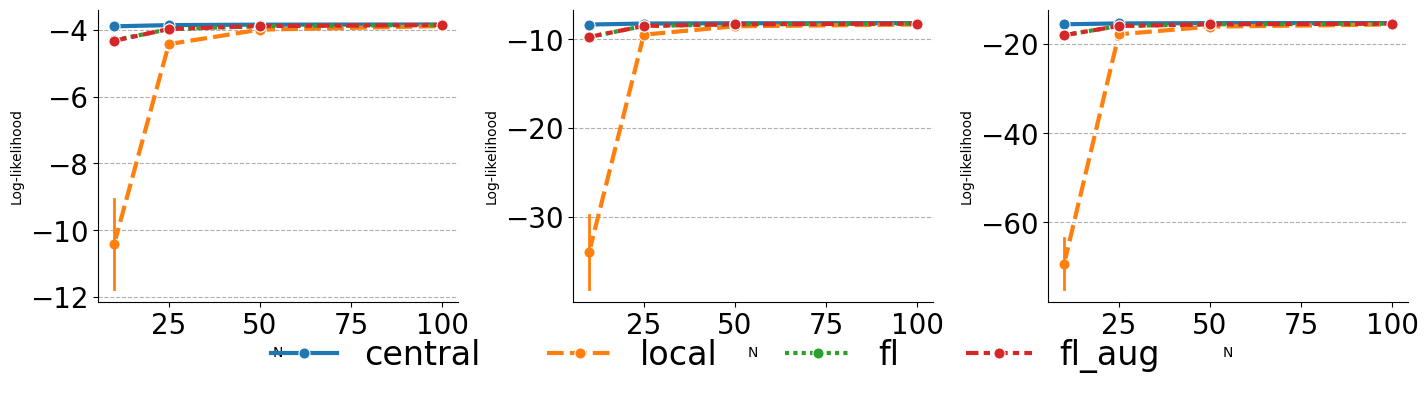

In [45]:
df_lskew_alpha02 =  df_lskew[ (df_lskew["alpha"]==0.2)]
df_lskew_alpha1  =  df_lskew[ (df_lskew["alpha"]==1)]
df_lskew_alpha10  =  df_lskew[ (df_lskew["alpha"]==10)]

plot_metrics(df_lskew_alpha02, "N", "Log-likelihood", "D")
plot_metrics(df_lskew_alpha1, "N", "Log-likelihood", "D")
plot_metrics(df_lskew_alpha10, "N", "Log-likelihood", "D")

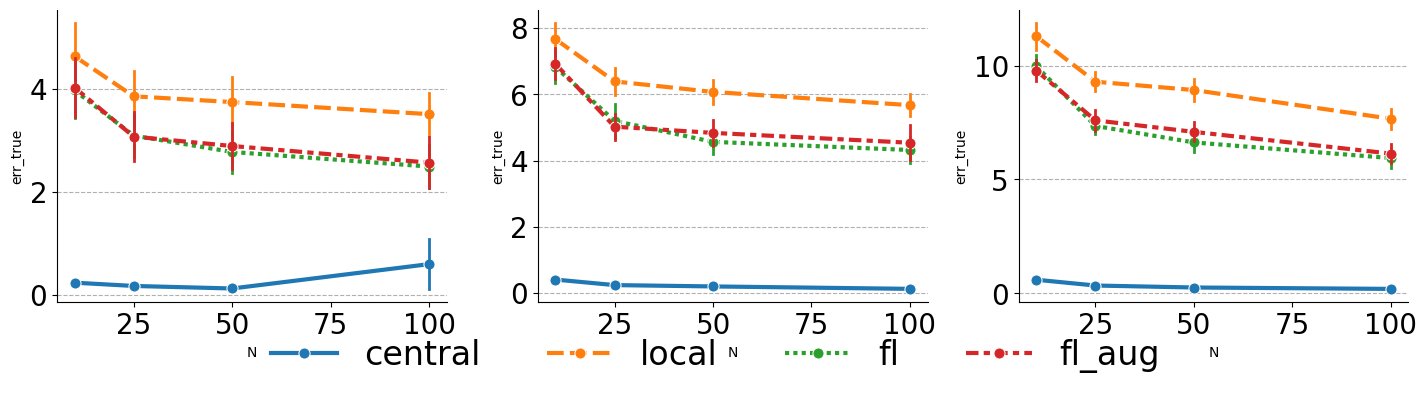

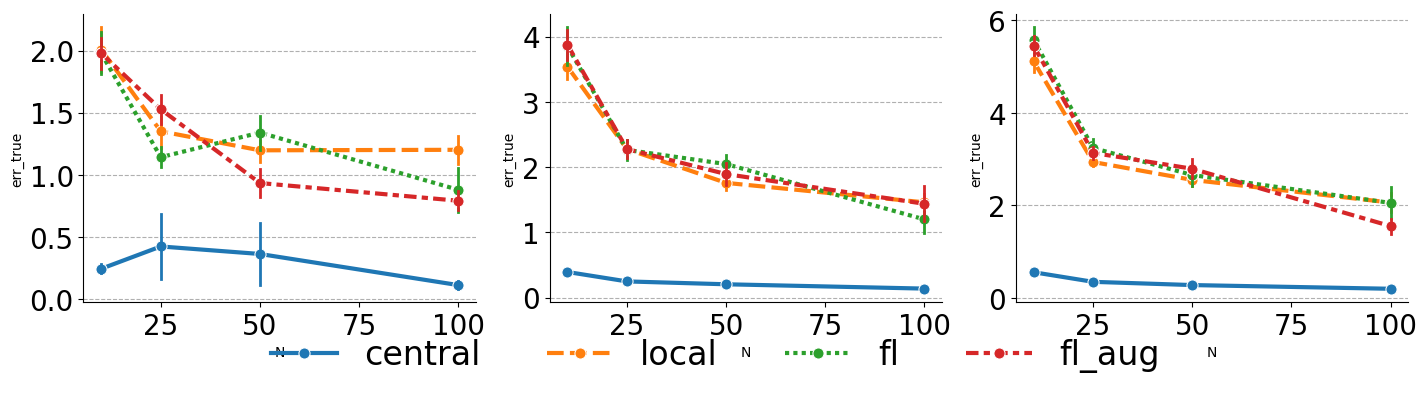

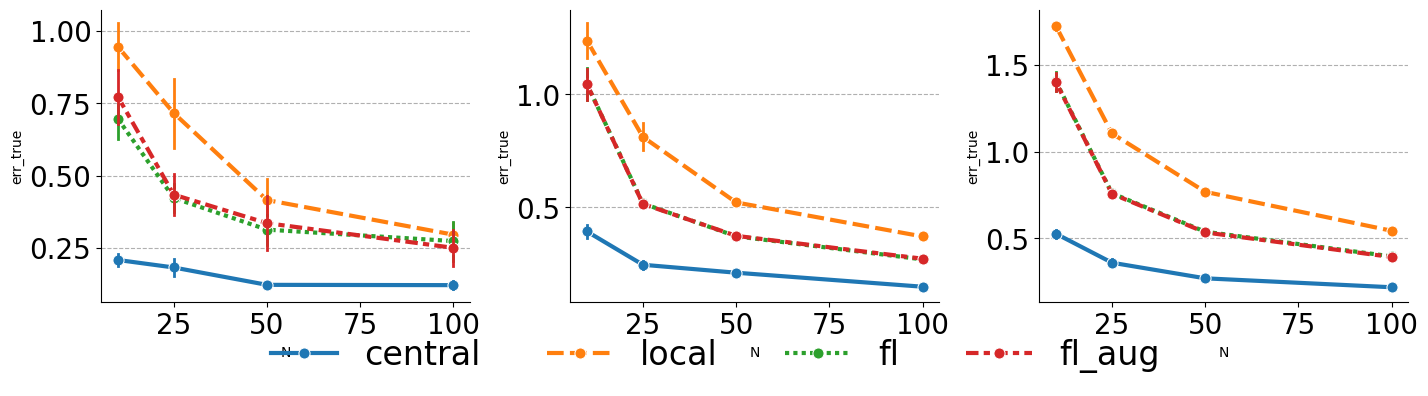

In [46]:
algorithms=["local", "central", "fl", "fl_aug"]
plot_metrics(df_lskew_alpha02, "N", "err_true", "D")
plot_metrics(df_lskew_alpha1, "N", "err_true", "D")
plot_metrics(df_lskew_alpha10, "N", "err_true", "D")

# MEANS SHIFT:

add gaussian noise to mean vector (to each component) to each client

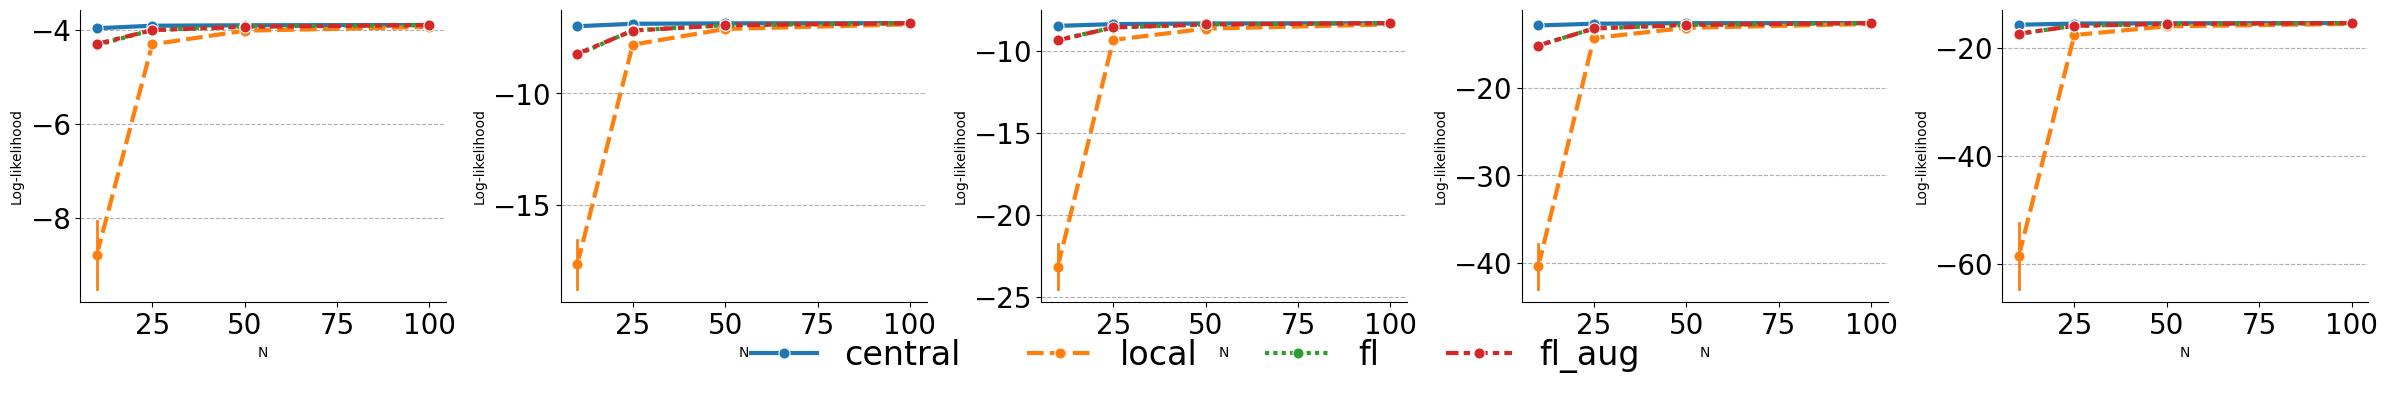

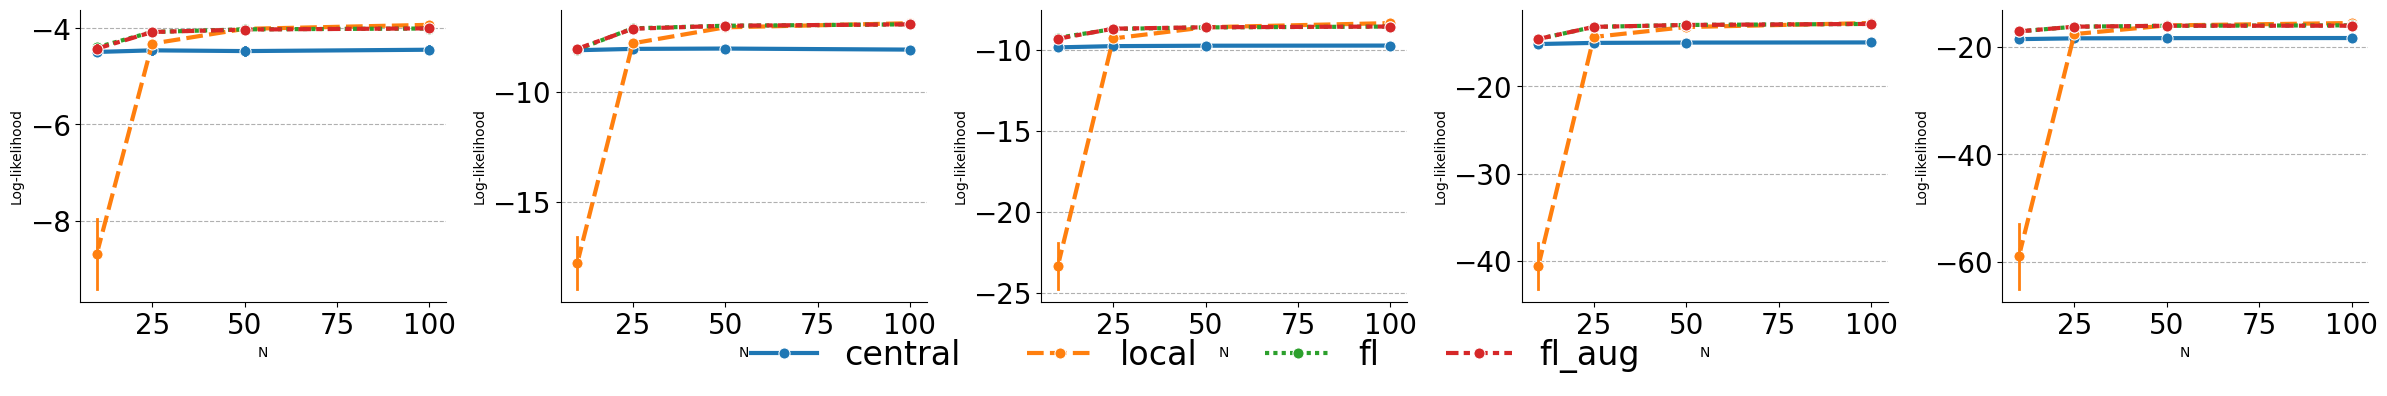

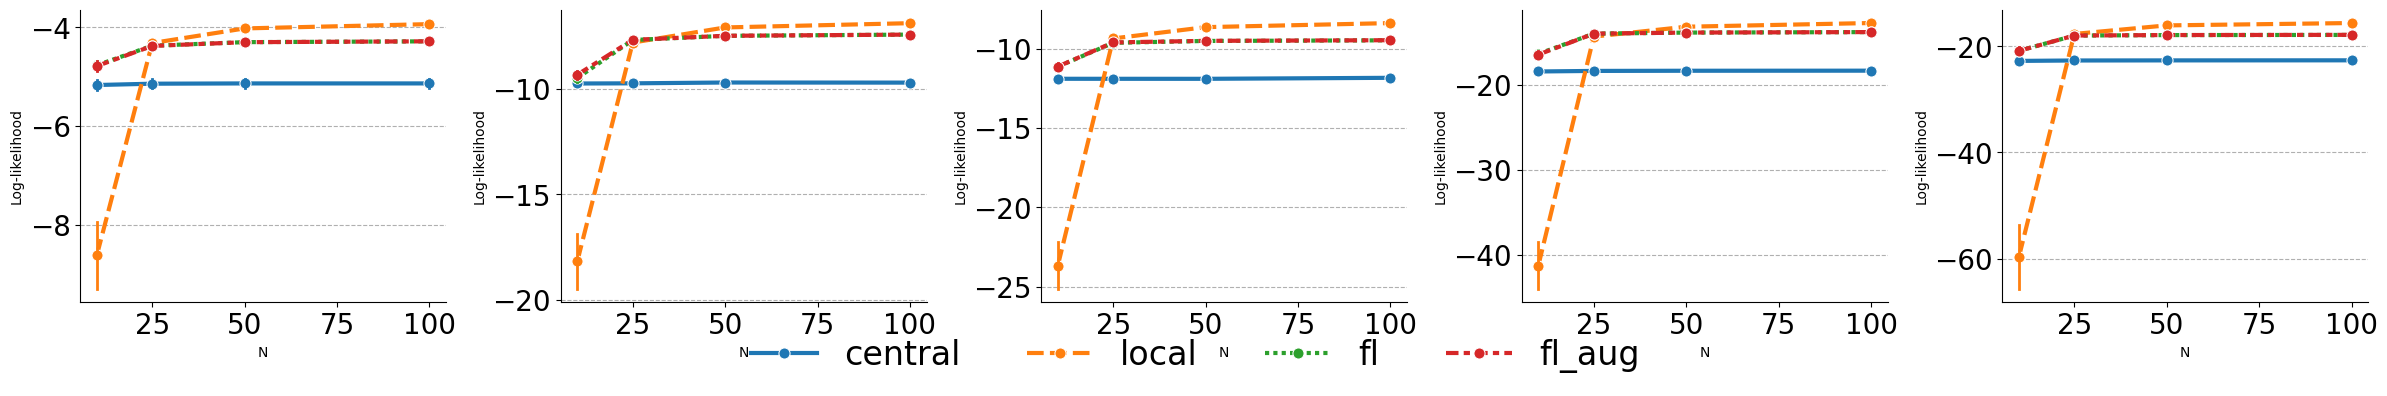

In [48]:
df_plot_ = df_shift[ (df_shift["algorithm"]!='local')]

df_shift02 =  df_shift[ (df_shift["shift_scale"]==0.2)]
df_shift1  =  df_shift[ (df_shift["shift_scale"]==1)]
df_shift2  =  df_shift[ (df_shift["shift_scale"]==2)]

plot_metrics(df_shift02, "N", "Log-likelihood", "D")
plot_metrics(df_shift1, "N", "Log-likelihood", "D")
plot_metrics(df_shift2, "N", "Log-likelihood", "D")

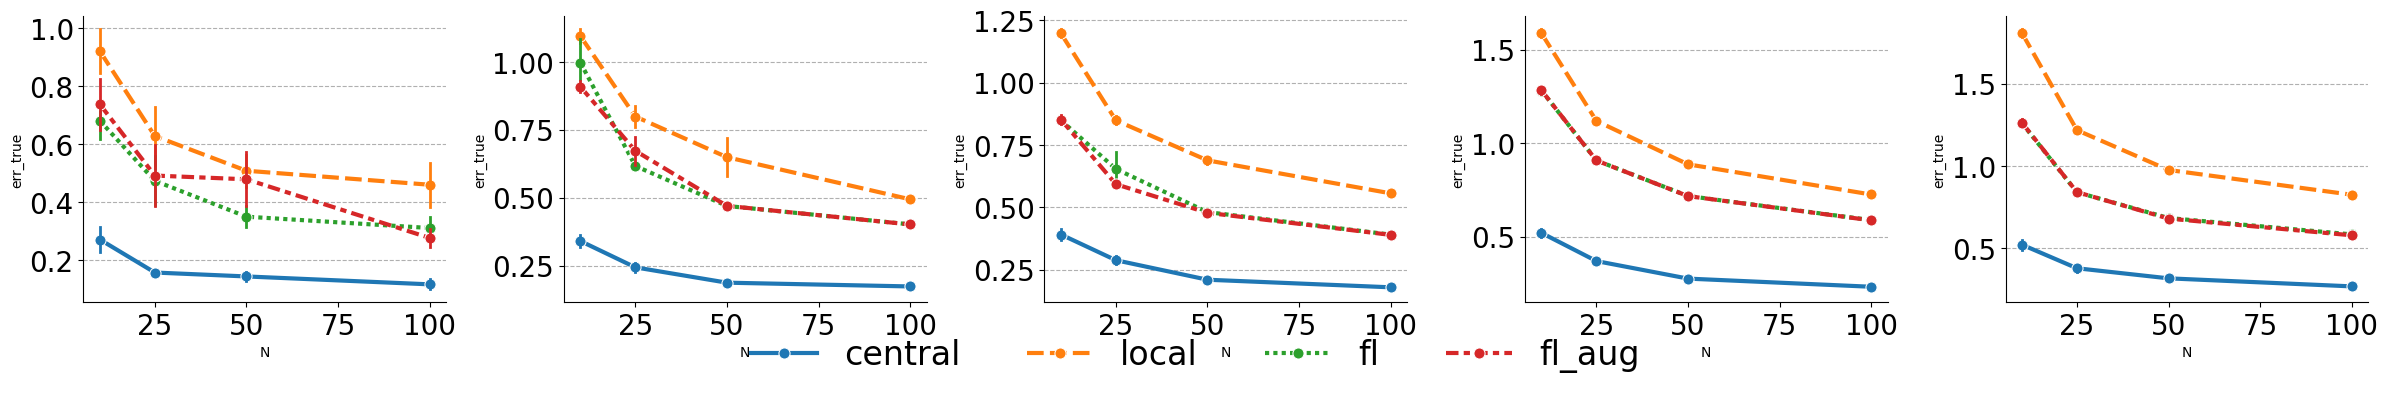

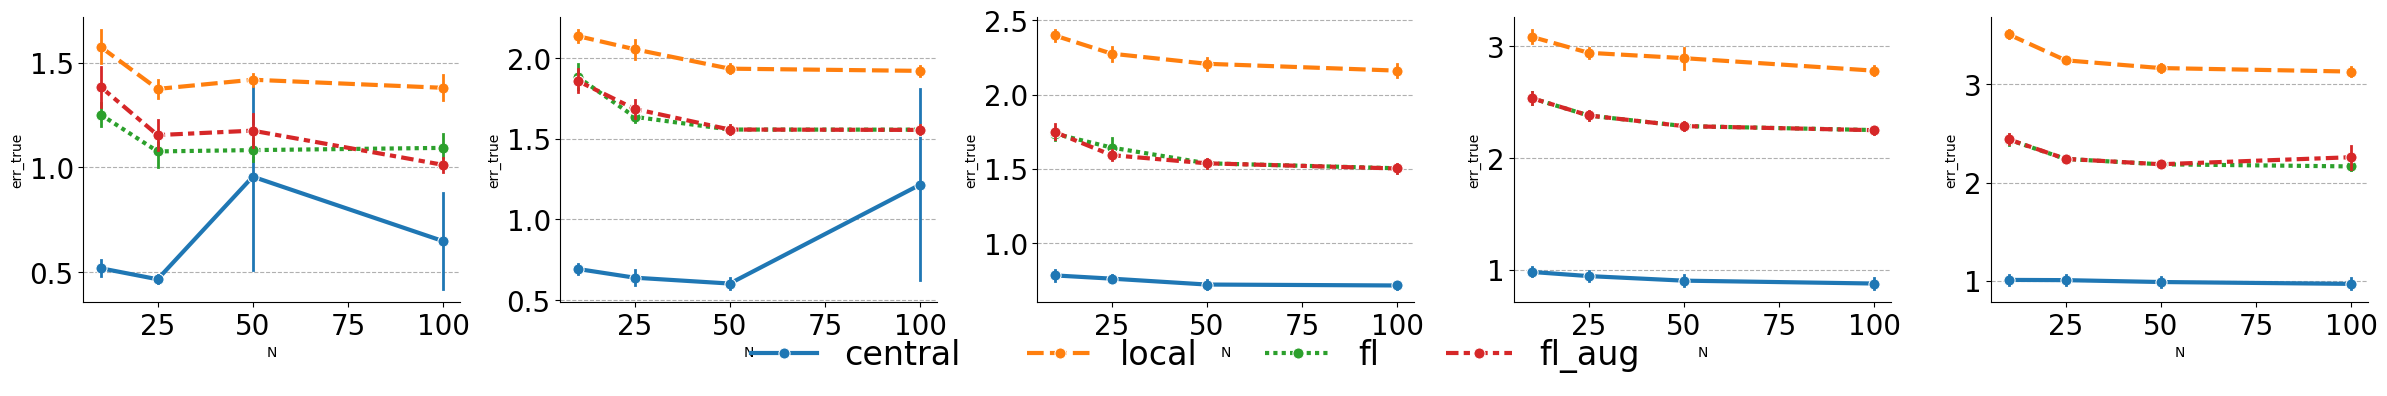

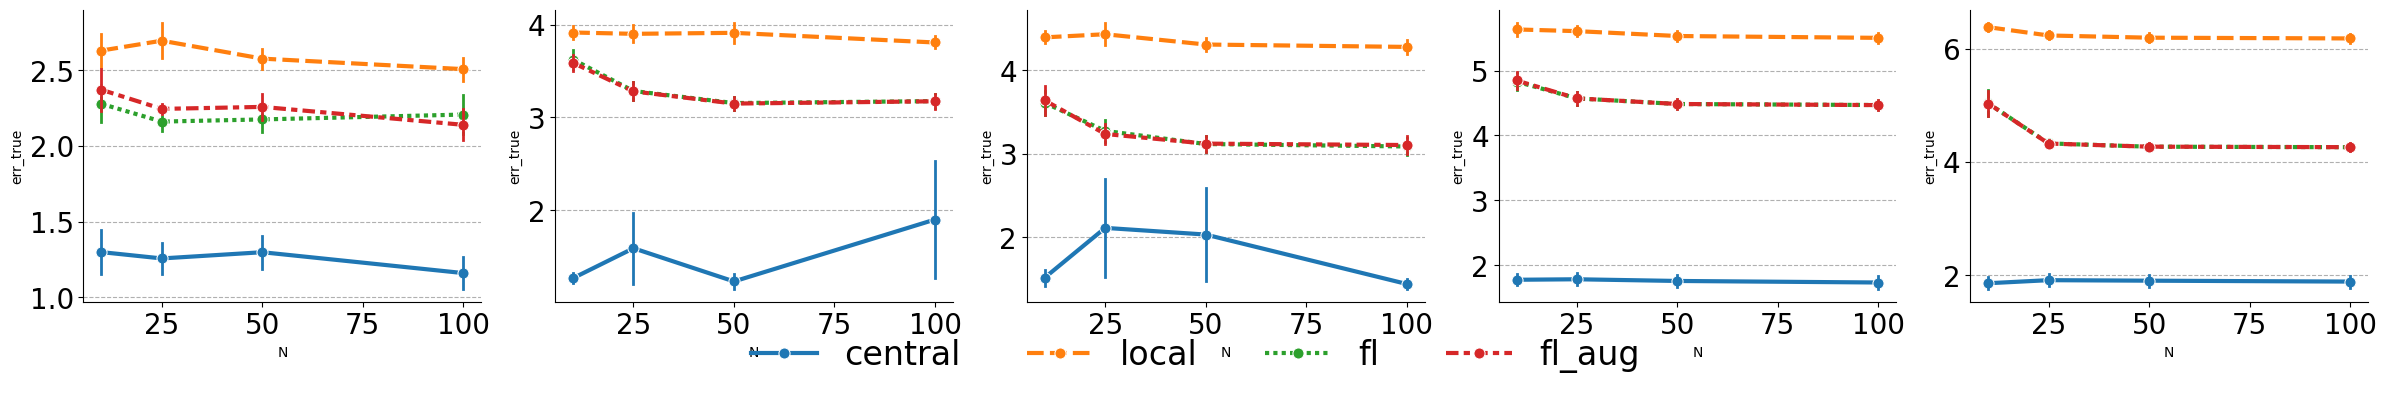

In [49]:
plot_metrics(df_shift02, "N", "err_true", "D")
plot_metrics(df_shift1, "N", "err_true", "D")
plot_metrics(df_shift2, "N", "err_true", "D")

# Cluster Drop

In [50]:
df_lambda_0 = df_cluster_drop[ (df_cluster_drop["lambda"]==0)]
df_lambda_05 = df_cluster_drop[ (df_cluster_drop["lambda"]==0.5)]
df_lambda_1 = df_cluster_drop[ (df_cluster_drop["lambda"]==1)]

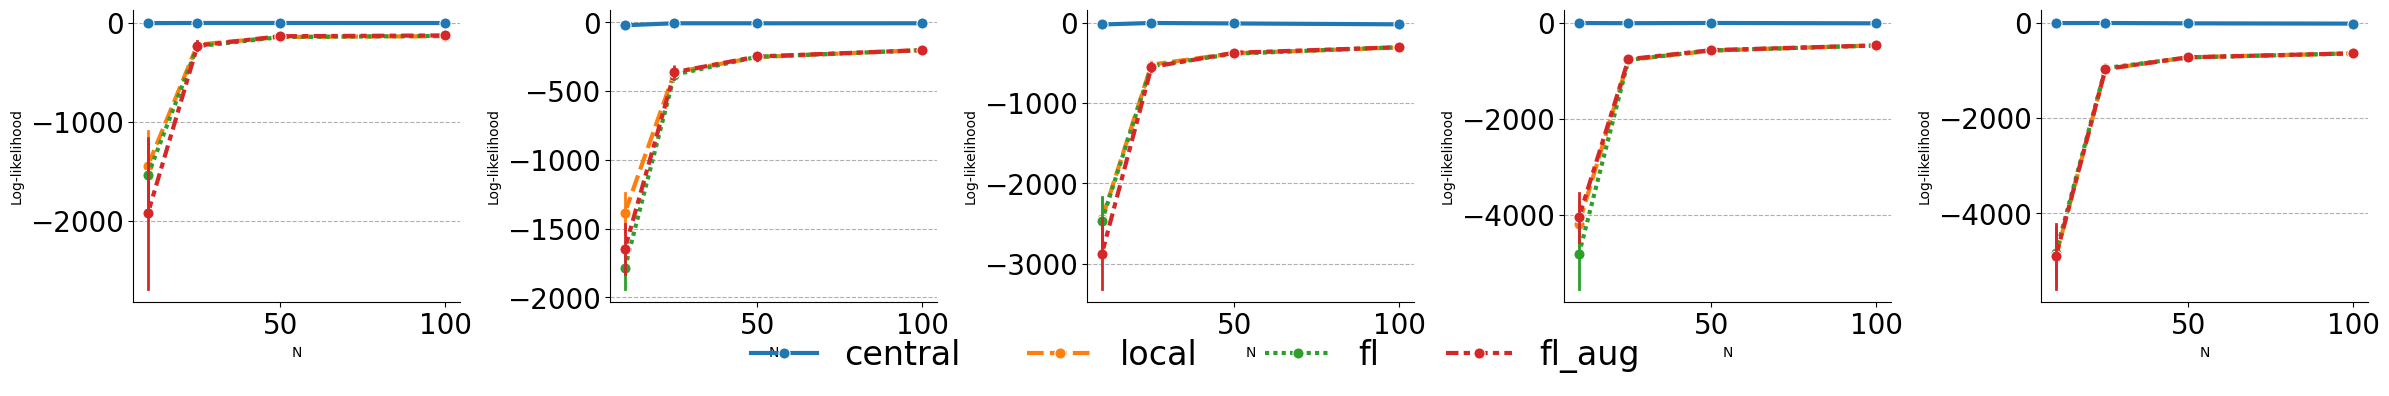

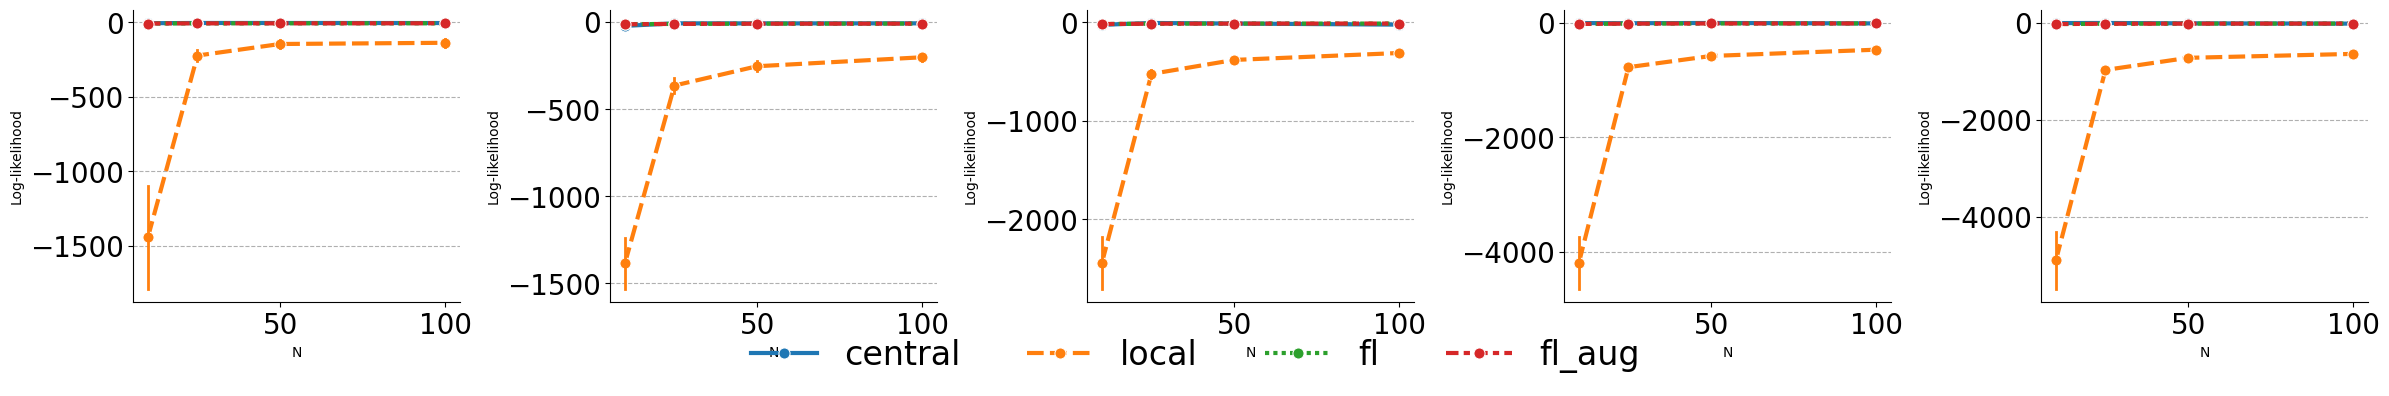

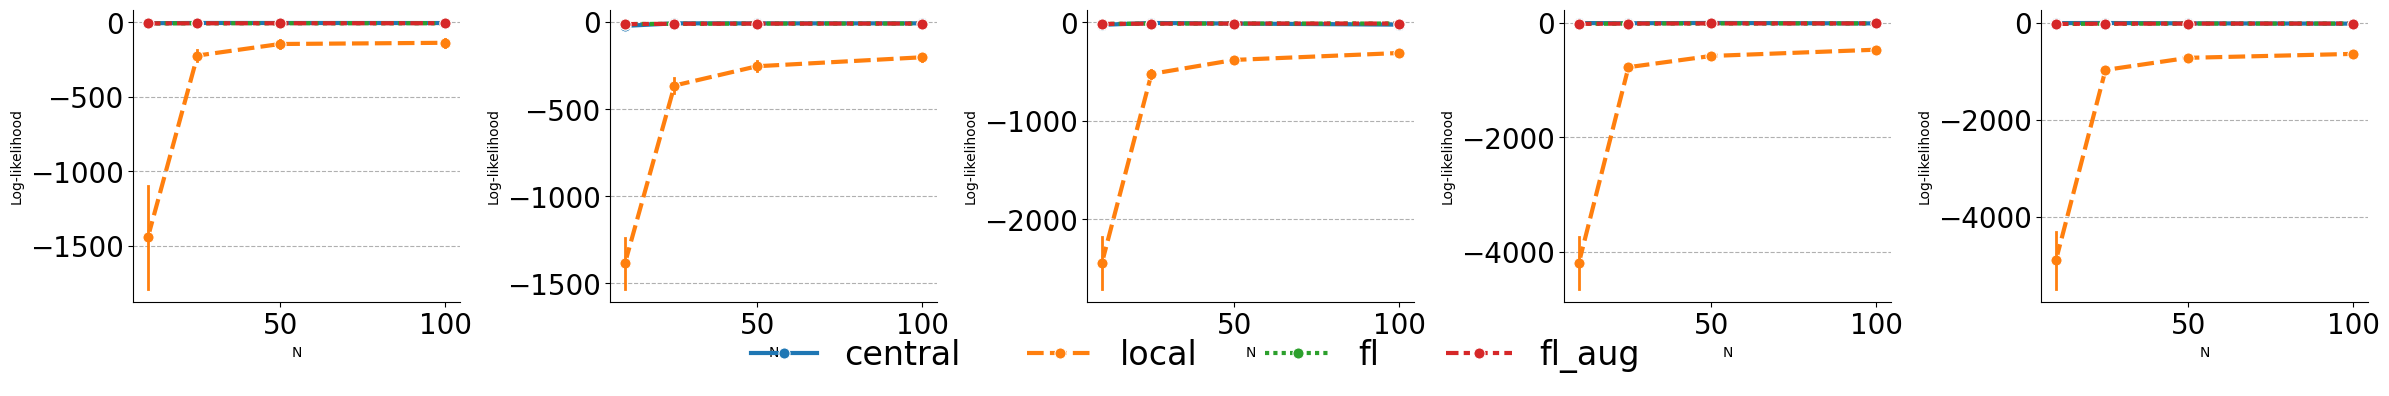

In [51]:
plot_metrics(df_lambda_0, "N", "Log-likelihood", "D")
plot_metrics(df_lambda_05, "N", "Log-likelihood", "D")
plot_metrics(df_lambda_1, "N", "Log-likelihood", "D")

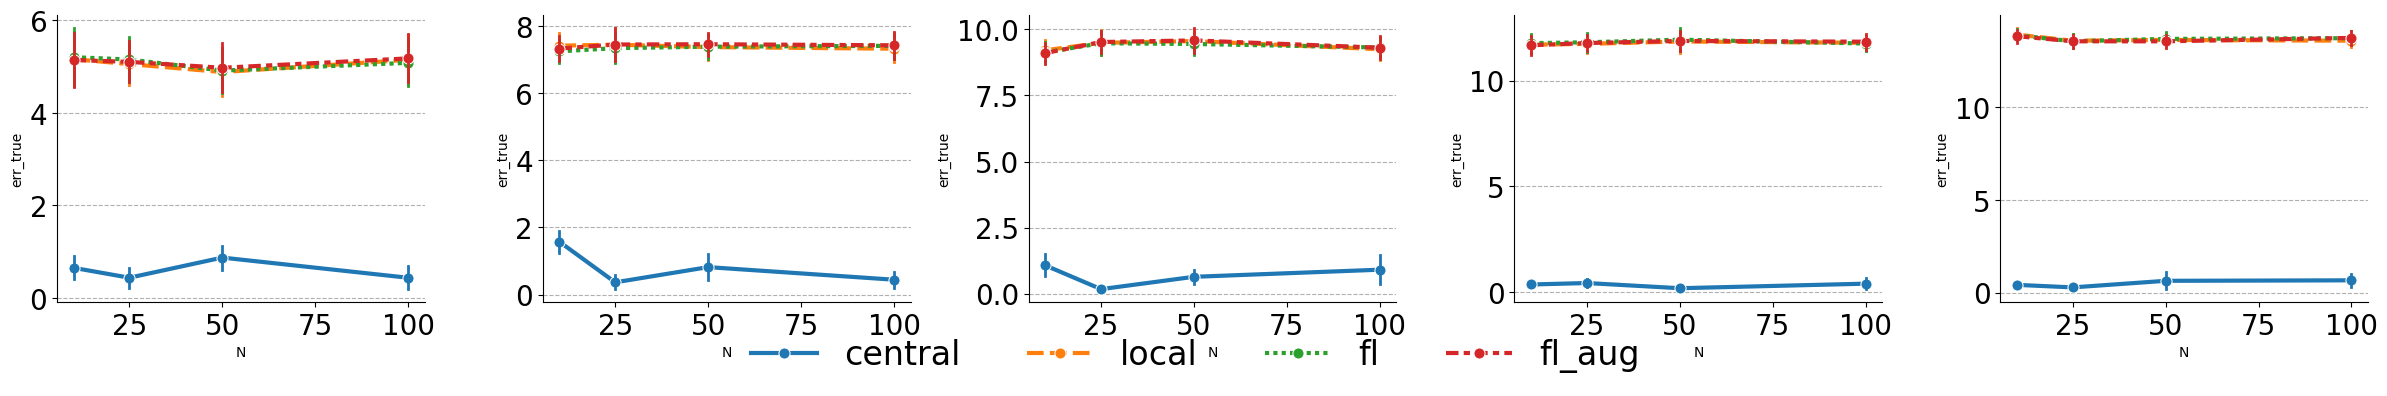

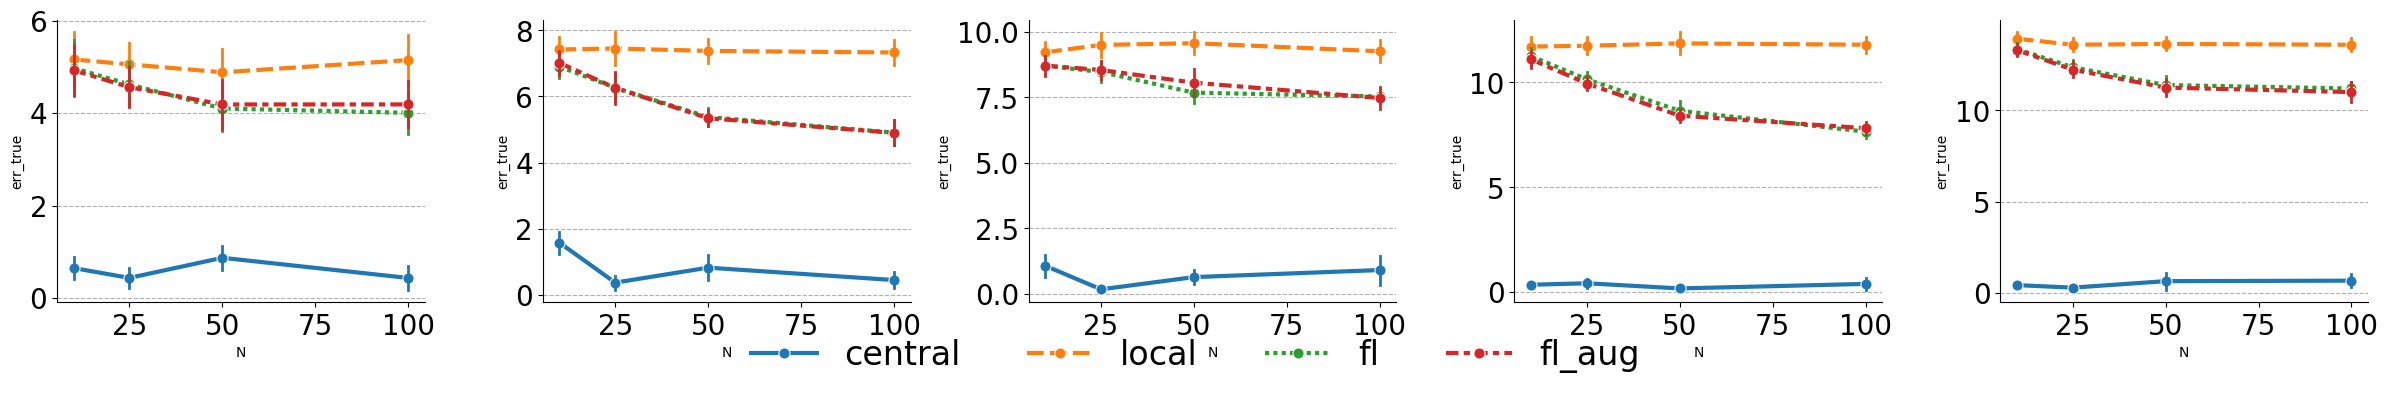

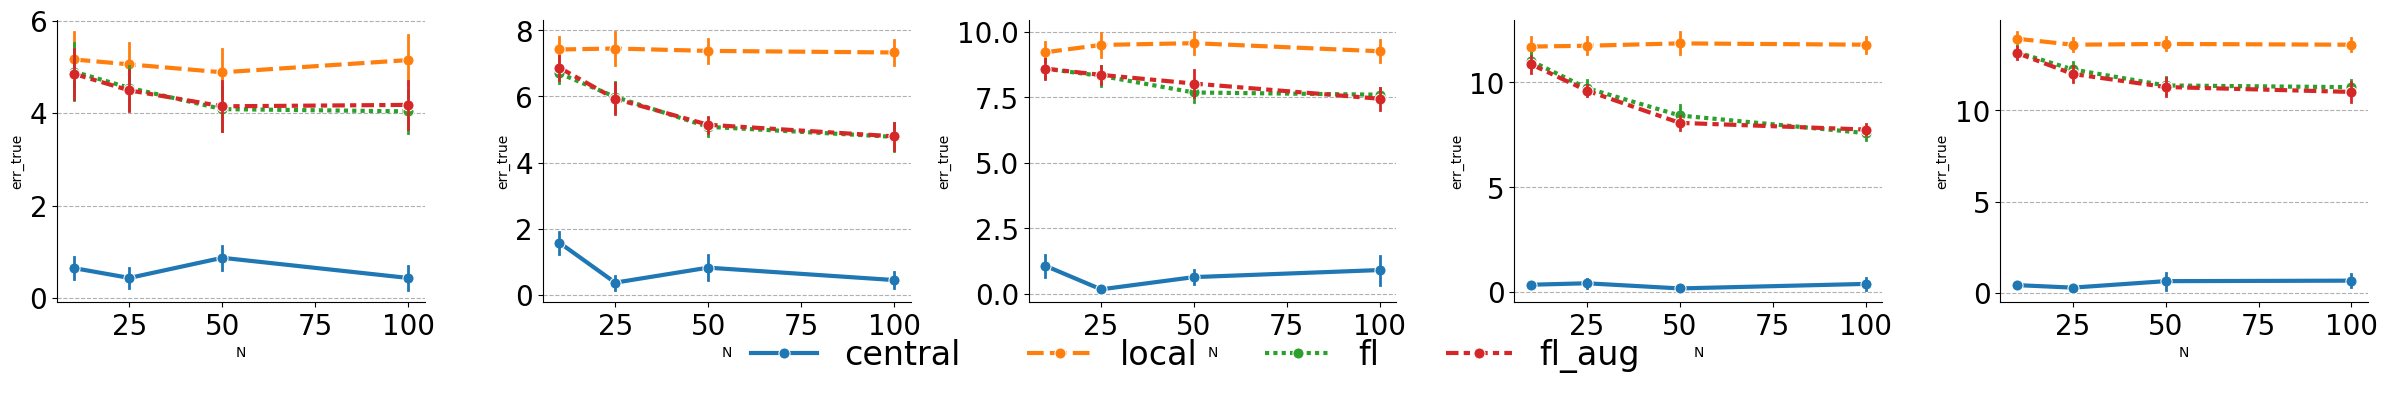

In [52]:
plot_metrics(df_lambda_0, "N", "err_true", "D")
plot_metrics(df_lambda_05, "N", "err_true", "D")
plot_metrics(df_lambda_1, "N", "err_true", "D")

# MNIST

In [34]:
df_mnist.head()

,n_clients,D,seed,N,alpha,lambda,lr,K,runtime_sec,algorithm,Log-likelihood,NMI,AMI
0,10,10,4,100,0.2,1,0.0005,10,2397.302240,central,15.816704,0.761133,0.760696
1,10,10,4,100,0.2,1,0.0005,10,2397.302240,local,-693.979514,0.486466,0.485492
2,10,10,4,100,0.2,1,0.0005,10,2397.302240,fl,5.564998,0.560679,0.559888
3,10,10,4,100,0.2,1,0.0005,10,2397.302240,fl_aug,12.292124,0.591350,0.590488
4,10,2,4,300,1.0,1,0.0005,10,2308.685989,central,-4.295726,0.760202,0.759774


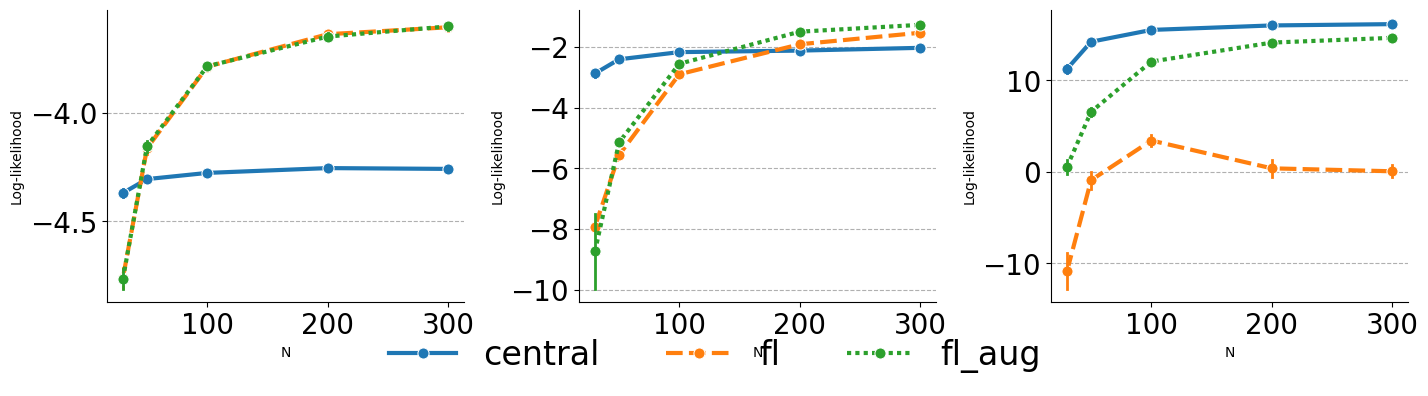

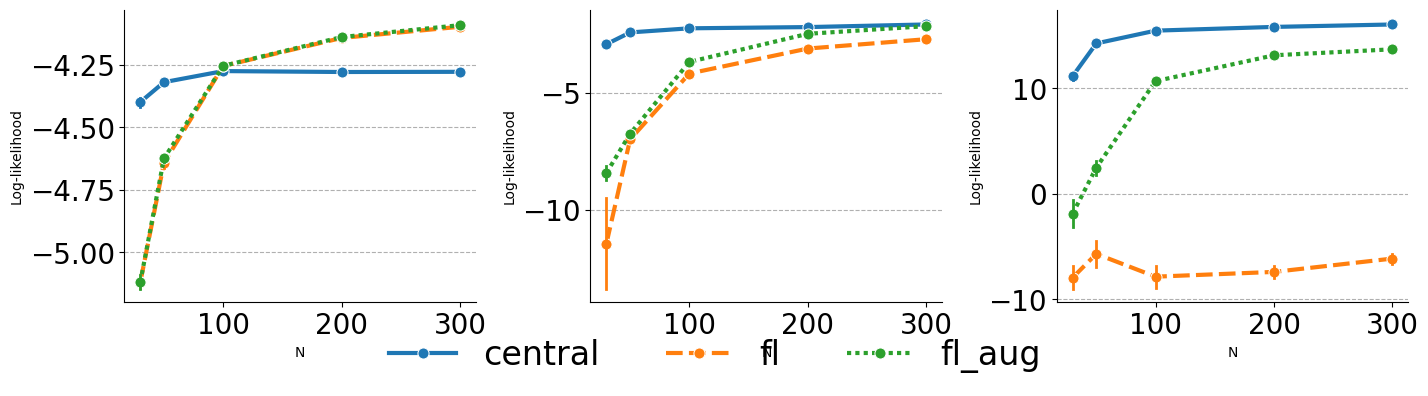

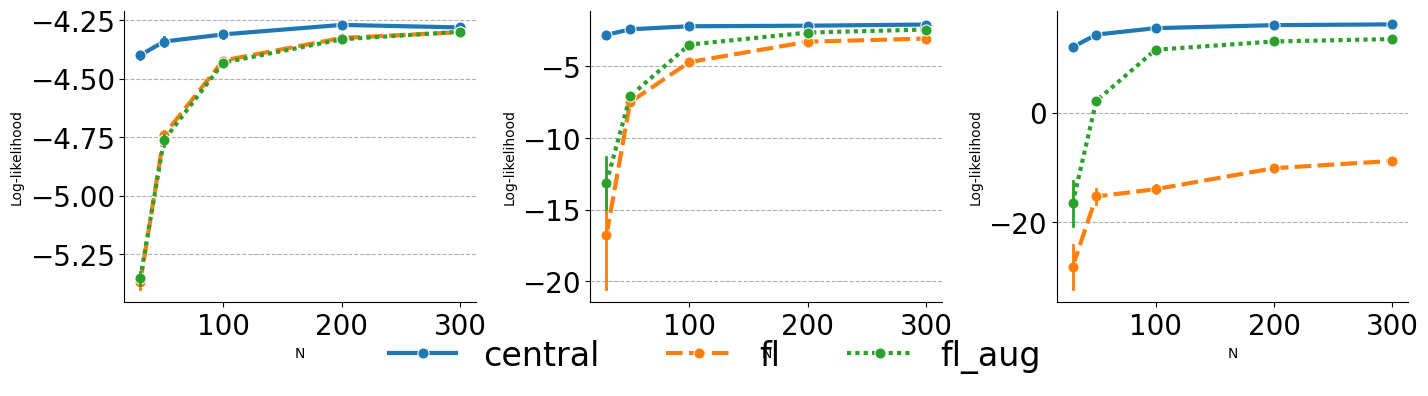

In [48]:
df_plot_ = df_mnist[ (df_mnist["algorithm"]!='local')]

df_mnist_alpha02 =  df_plot_[ (df_plot_["alpha"]==0.2)]
df_mnist_alpha1  =  df_plot_[ (df_plot_["alpha"]==1)]
df_mnist_alpha10  =  df_plot_[ (df_plot_["alpha"]==10)]

plot_metrics(df_mnist_alpha02, "N", "Log-likelihood", "D")
plot_metrics(df_mnist_alpha1, "N", "Log-likelihood", "D")
plot_metrics(df_mnist_alpha10, "N", "Log-likelihood", "D")

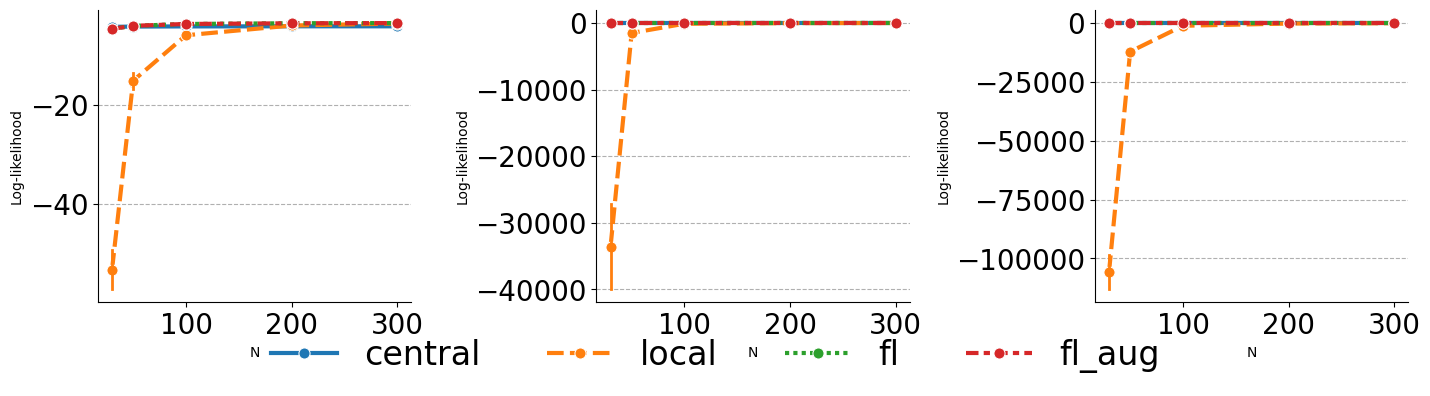

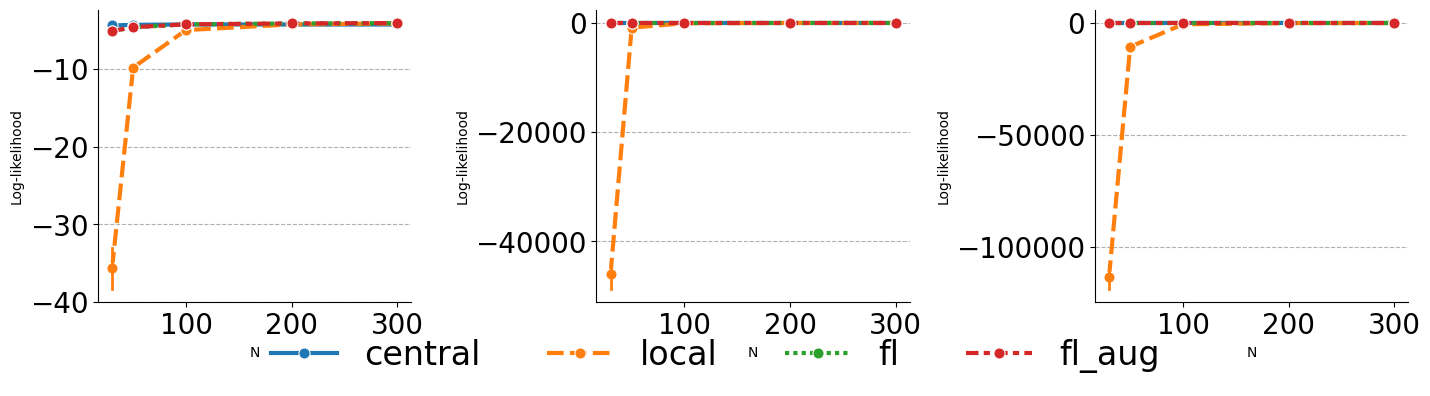

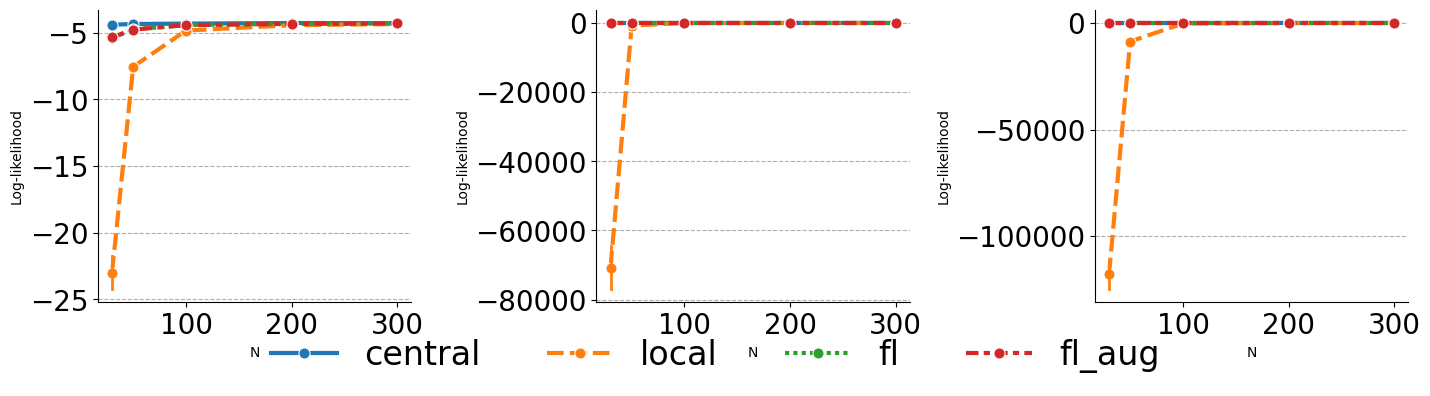

In [43]:
df_mnist_alpha02 =  df_mnist[ (df_mnist["alpha"]==0.2)]
df_mnist_alpha1  =  df_mnist[ (df_mnist["alpha"]==1)]
df_mnist_alpha10  =  df_mnist[ (df_mnist["alpha"]==10)]

plot_metrics(df_mnist_alpha02, "N", "Log-likelihood", "D")
plot_metrics(df_mnist_alpha1, "N", "Log-likelihood", "D")
plot_metrics(df_mnist_alpha10, "N", "Log-likelihood", "D")

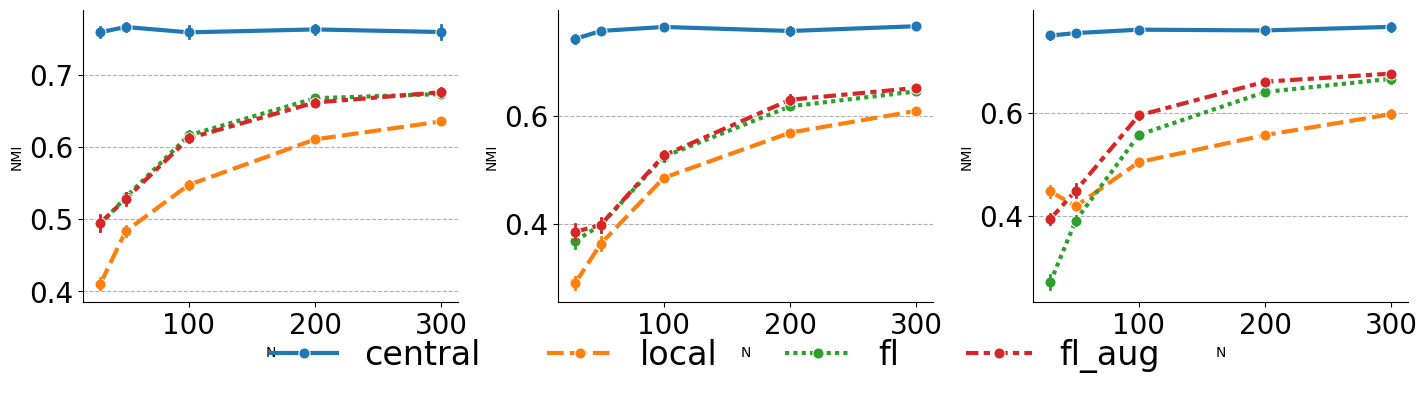

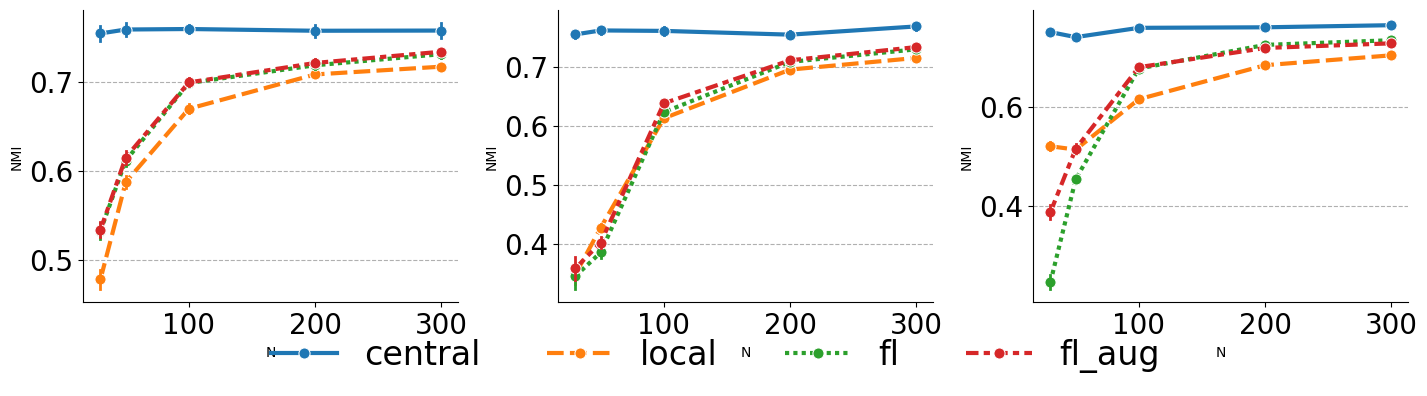

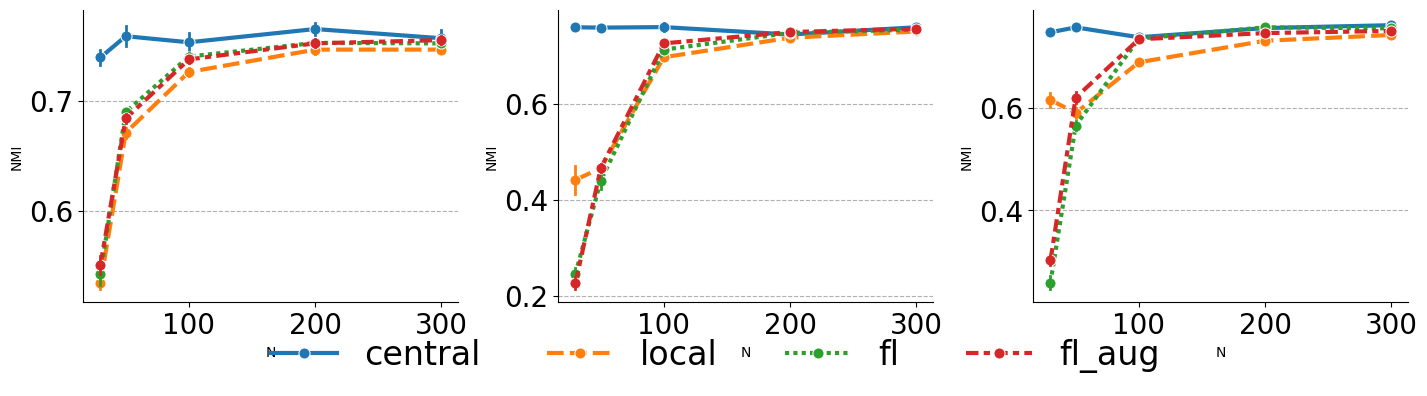

In [36]:
# N_LIST=(30 50 100 200 300)
# D_LIST=(2 5 10)
plot_metrics(df_mnist_alpha02, "N", "NMI", "D")
plot_metrics(df_mnist_alpha1, "N", "NMI", "D")
plot_metrics(df_mnist_alpha10, "N", "NMI", "D")

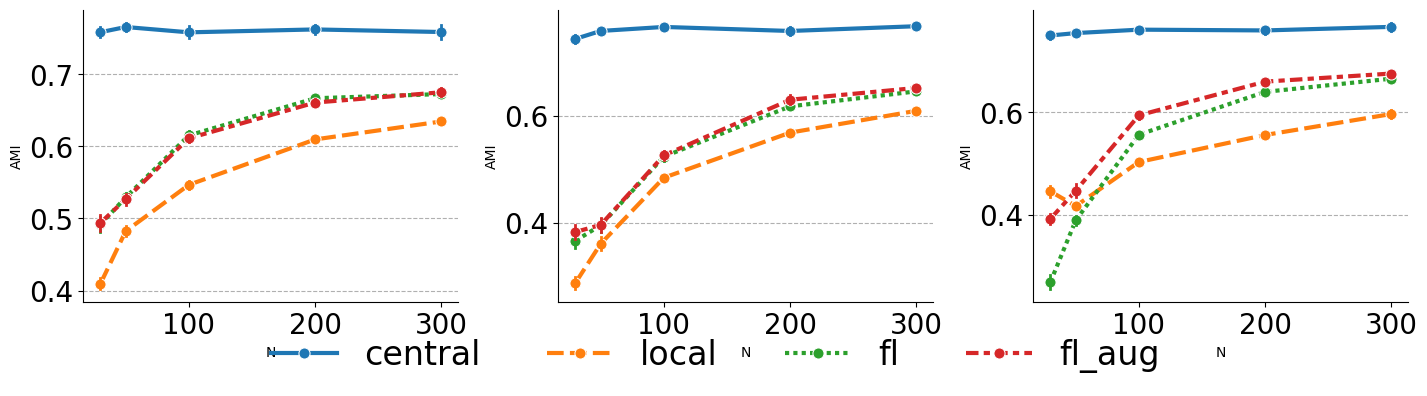

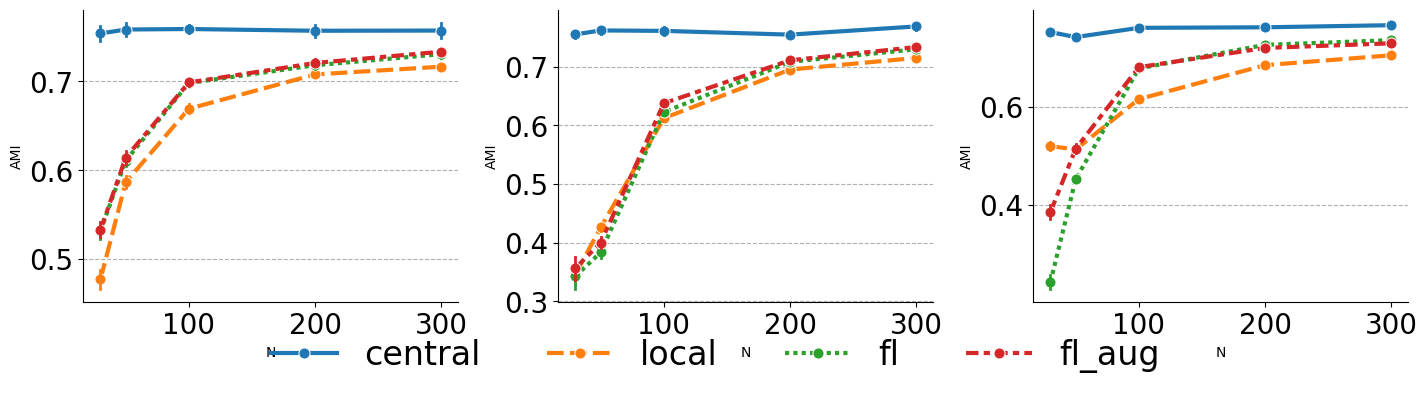

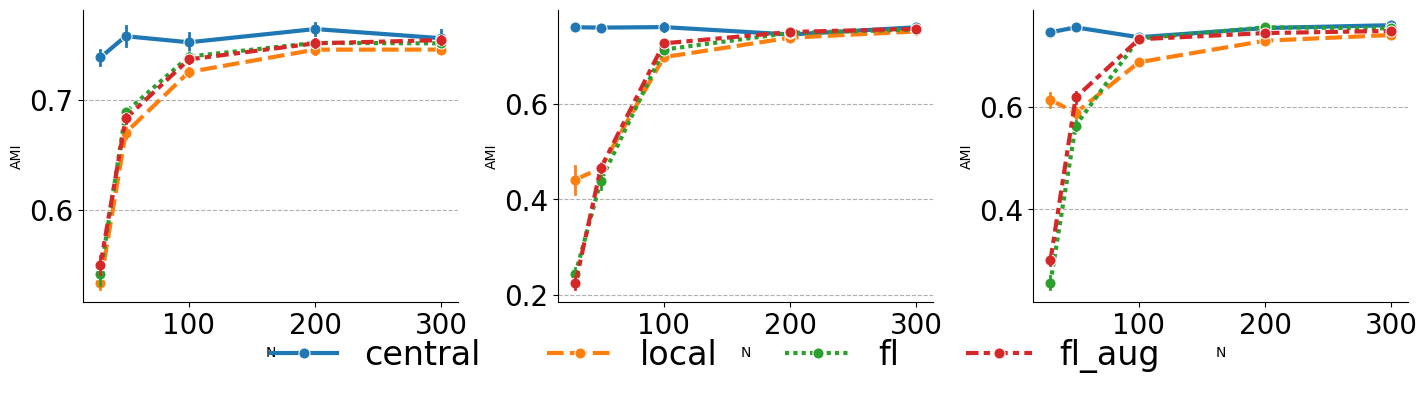

In [37]:
plot_metrics(df_mnist_alpha02, "N", "AMI", "D")
plot_metrics(df_mnist_alpha1, "N", "AMI", "D")
plot_metrics(df_mnist_alpha10, "N", "AMI", "D")

In [56]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from torchvision import datasets
import umap

/Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <367D4265-B20F-34BD-94EB-4F3EE47C385B> /Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/site-packages/torchvision/image.so
  Reason: tried: '/Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/abduras1/miniconda3/envs/hetFL/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, 

In [57]:
def load_raw_mnist():
    mnist = datasets.MNIST(root="./data", train=True, download=True)
    X = mnist.data.numpy().reshape(-1, 28*28) / 255.0
    y = mnist.targets.numpy()
    return X, y

def split_client_data(X_i, y_i, n_samples, n_samples_val, rng):
    """
    Split per-client data preserving class proportions approximately,
    but limit total samples to n_samples + n_samples_val.
    """
    N = n_samples + n_samples_val

    # Global index pool
    all_idxs = np.arange(len(X_i))

    X_train, X_val, y_train, y_val = [], [], [], []
    
    # Get class proportions for client
    classes, counts = np.unique(y_i, return_counts=True) # e.g. (array([0, 1, 2, 3, 4]), array([3, 3, 2, 1, 1]))
    proportions = counts / counts.sum()
    
    # Allocate number of samples per class based on proportions
    n_per_class = (proportions * N).astype(int)
    # Fix rounding mismatch
    diff = N - n_per_class.sum()
    if diff != 0:
        adjust_classes = rng.choice(len(n_per_class), size=abs(diff), replace=True)
        for i in adjust_classes:
            n_per_class[i] += np.sign(diff)
    # remove negative sample count
    n_per_class = np.clip(n_per_class, 0, None)
    used_idxs = set()

    # Sample per class
    for c, n_c_target in zip(classes, n_per_class):
        idxs_c = np.where(y_i == c)[0]
        rng.shuffle(idxs_c)
        idxs_c = idxs_c[:n_c_target]

        used_idxs.update(idxs_c.tolist())

        n_train_c = int(len(idxs_c) * n_samples / N)

        X_train.append(X_i[idxs_c[:n_train_c]])
        y_train.append(y_i[idxs_c[:n_train_c]])

        X_val.append(X_i[idxs_c[n_train_c:]])
        y_val.append(y_i[idxs_c[n_train_c:]])
    # account for zero sample class with np.empty
    X_train = np.concatenate(X_train) if X_train else np.empty((0, X_i.shape[1]))
    y_train = np.concatenate(y_train) if y_train else np.empty((0,), dtype=y_i.dtype)

    X_val = np.concatenate(X_val) if X_val else np.empty((0, X_i.shape[1]))
    y_val = np.concatenate(y_val) if y_val else np.empty((0,), dtype=y_i.dtype)

    # Remaining unused indices
    remaining_idxs = np.array(list(set(all_idxs) - used_idxs))
    rng.shuffle(remaining_idxs)

    # Top up train set
    if len(X_train) < n_samples:
        needed = n_samples - len(X_train)
        extra = remaining_idxs[:needed]
        remaining_idxs = remaining_idxs[needed:]

        X_train = np.concatenate([X_train, X_i[extra]])
        y_train = np.concatenate([y_train, y_i[extra]])

    # Top up validation set
    if len(X_val) < n_samples_val:
        needed = n_samples_val - len(X_val)
        extra = remaining_idxs[:needed]

        X_val = np.concatenate([X_val, X_i[extra]])
        y_val = np.concatenate([y_val, y_i[extra]])

    return X_train[:n_samples], X_val[:n_samples_val], y_train[:n_samples], y_val[:n_samples_val]

def generate_data_mnist(n_clients=10,
                        n_clusters=6,
                        n_samples=100,
                        n_samples_val=500,
                        n_features=2,
                        seed=0,
                        alpha=0.5,
                        dimred='umap'):
        
    rng = np.random.default_rng(seed=seed)
    X_raw, y = load_raw_mnist() # shapes (60000, 784) and (60000,)

    # ----------------------------------------------------------------------
    # Split global dataset: reserve 10k stratified for dimensionality reduction
    # ----------------------------------------------------------------------
    X_dimred, X_split, y_dimred, y_split = train_test_split(
        X_raw, y, train_size=10000, stratify=y)

    # ----------------------------------------------------------------------
    # Prepare class-wise index groups from the remaining data (50k)
    # ----------------------------------------------------------------------

    # Group indices by class
    indices_by_class = {k: np.where(y_split == k)[0] for k in range(10)}
    # Shuffle samples within the class
    for idxs in indices_by_class.values():
        rng.shuffle(idxs)
        
    counter = 0
    valid_split = False
    while (counter < 20) and (valid_split == False):
        client_indices = [[] for _ in range((n_clients))] # create empty lists
        label_proportions = np.zeros((n_clients, 10)) # proportions of ALL classes for each local node 

        for k in range(n_clusters):
            idxs = indices_by_class[k] # get indices for class `k`
            # create list of len(n_clients) filled with val alpha and use it
            # to get simplex for class `k` over n_ds datasets, e.g. array([0.003, 0.812, 0.002, 0.176, 0.007])
            proportions = rng.dirichlet([alpha] * n_clients)
            """
            - multiply proportions by the total number of samples in this class.
            This tells roughly where to cut the sorted indices for digit k:
            e.g. [0.2, 0.5, 0.3] --> [0.2, 0.7, 1. ]* 90 -> [ 18.0,  63.0, 90.0]
            - convert to int and drop last ellement -> [18, 63]
            - split_idxs = np.split(idxs, [18, 63]). This results in 3 chunks:
            idxs[0:18] -> 18 samples to client 0
            idxs[18:63] -> 45 samples to client 1
            idxs[63:90] -> 27 samples to client 2
            That matches the Dirichlet proportions: [0.2, 0.5, 0.3]
            """
            proportions = (np.cumsum(proportions) * len(idxs)).astype(int)[:-1]
            split_idxs = np.split(idxs, proportions)
            for client_id, idx_set in enumerate(split_idxs):
                client_indices[client_id].extend(idx_set)
                label_proportions[client_id, k] = len(idx_set)
            
        # check if there are enough datapoints
        valid_split = all(len(idxs) >= n_samples + n_samples_val for idxs in client_indices)
        counter+=1
    if not valid_split: raise ValueError("Failed to generate valid client splits after 20 attempts.")
    # normalize to get class distribution per client
    label_proportions = label_proportions / label_proportions.sum(axis=1, keepdims=True)

    # ----------------------------------------------------------------------
    # Fit dimensionality reducer on the reserved 10k subset
    # ----------------------------------------------------------------------
    if dimred == 'pca':
        reducer = PCA(n_components=n_features)
        reducer.fit(X_dimred)
    elif dimred == 'umap':
        reducer = umap.UMAP(n_components=n_features, random_state=seed)
        reducer.fit(X_dimred)
    else:
        raise ValueError("dimred must be 'umap' or 'pca'.")
        
    # ----------------------------------------------------------------------
    # Generate per-client datasets
    # ----------------------------------------------------------------------
    client_data, client_data_val, = [], []
    client_labels, client_labels_val = [], []

    for i, idxs in enumerate(client_indices):
        X_i, y_i = X_split[idxs], y_split[idxs]
        X_train, X_val, y_train, y_val = split_client_data(X_i, y_i, n_samples, n_samples_val, rng)

        client_data.append(reducer.transform(X_train))
        client_data_val.append(reducer.transform(X_val))
        
        client_labels.append(y_train)
        client_labels_val.append(y_val)

    return np.array(client_data), np.array(client_data_val), np.array(client_labels), np.array(client_labels_val), label_proportions


In [58]:
def plot_label_distribution_scatter(label_proportions, scale=1000):
    """
    Plots a scatter plot (bubble plot) of digit distributions per client.
    
    Parameters
    ----------
    label_proportions : ndarray, shape (n_clients, 10)
        Each row represents a client and each column a digit (0–9). Values
        are the proportions (or counts) of a given digit for that client.
    scale : float, optional
        A scaling factor to adjust the marker sizes.
    """
    n_clients, n_labels = label_proportions.shape
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Choose a color map that can differentiate 10 categories
    # cmap = plt.get_cmap("tab10")
    digit_palette = {
    0: "#003f5c",  # Deep navy (matches GraphFed-EM family)
    1: "#2f4b7c",  # Slightly lighter navy-blue
    2: "#665191",  # Purple (ties with Oracle Aggr)
    3: "#a05195",  # Magenta-purple
    4: "#d45087",  # Pinkish red (bridges to Oracle Pool)
    5: "#f95d6a",  # Warm red
    6: "#ff7c43",  # Orange (matches Local)
    7: "#ffa600",  # Yellow-orange
    8: "#7aa926",  # Fresh green (ties with Centralized)
    9: "#2ca02c",  # Strong green (Centralized main)
}
    
    for client in range(n_clients):
        for digit in range(n_labels):
            proportion = label_proportions[client, digit]
            size = proportion * scale  # Adjust the bubble size by the scaling factor
            ax.scatter(client, digit, s=size, color=digit_palette[digit], alpha=0.7,
                       edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel("Client ID", fontsize=18)
    ax.set_ylabel("Digit", fontsize=18)
    # ax.set_title("Label distribution per client", fontsize=18)
    ax.set_xticks(np.arange(n_clients))
    ax.set_yticks(np.arange(n_labels))
    ax.grid(False)
    plt.tight_layout()
    plt.savefig("figs/MNIST_labels.pdf", bbox_inches="tight", dpi=300)
    plt.show()

/Users/abduras1/miniconda3/envs/hetFL/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


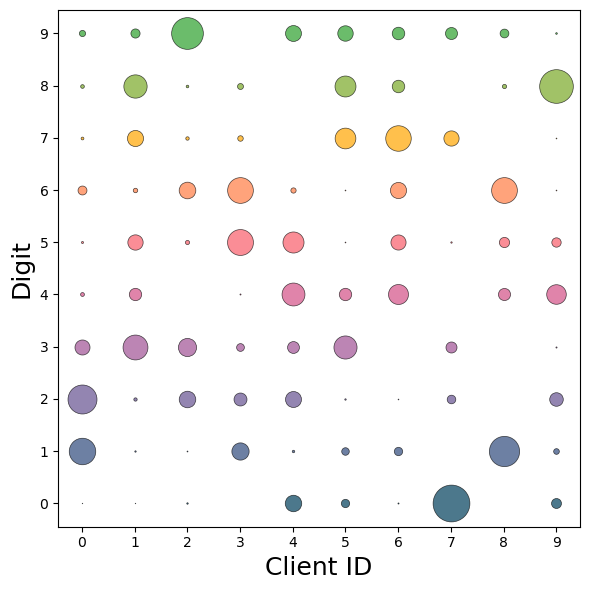

In [64]:
seed=0
np.random.seed(seed)

client_data, client_data_val, client_labels, client_labels_val, label_proportions = generate_data_mnist(n_clients=10,
                        n_clusters=10,
                        n_samples=100,
                        n_samples_val=100,
                        n_features=2,
                        seed=seed,
                        alpha=0.2,
                        dimred='umap')
plot_label_distribution_scatter(label_proportions)

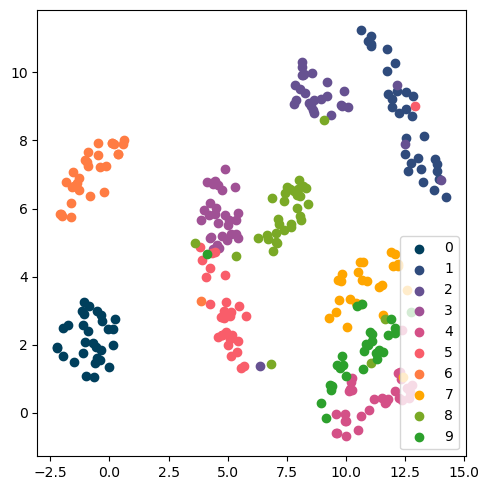

In [104]:
X_all = np.concatenate(client_data)
y_all = np.concatenate(client_labels)

fig, axs = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(5, 5))

digit_palette = {
    0: "#003f5c",  # Deep navy (matches GraphFed-EM family)
    1: "#2f4b7c",  # Slightly lighter navy-blue
    2: "#665191",  # Purple (ties with Oracle Aggr)
    3: "#a05195",  # Magenta-purple
    4: "#d45087",  # Pinkish red (bridges to Oracle Pool)
    5: "#f95d6a",  # Warm red
    6: "#ff7c43",  # Orange (matches Local)
    7: "#ffa600",  # Yellow-orange
    8: "#7aa926",  # Fresh green (ties with Centralized)
    9: "#2ca02c",  # Strong green (Centralized main)
}

for i in range(10):
    idx = np.where(y_all==i)[0]
    x, y = X_all[idx][:,0], X_all[idx][:,1]
    axs.scatter(x, y, c=digit_palette[i])

plt.legend(digit_palette)
plt.tight_layout()
plt.show()

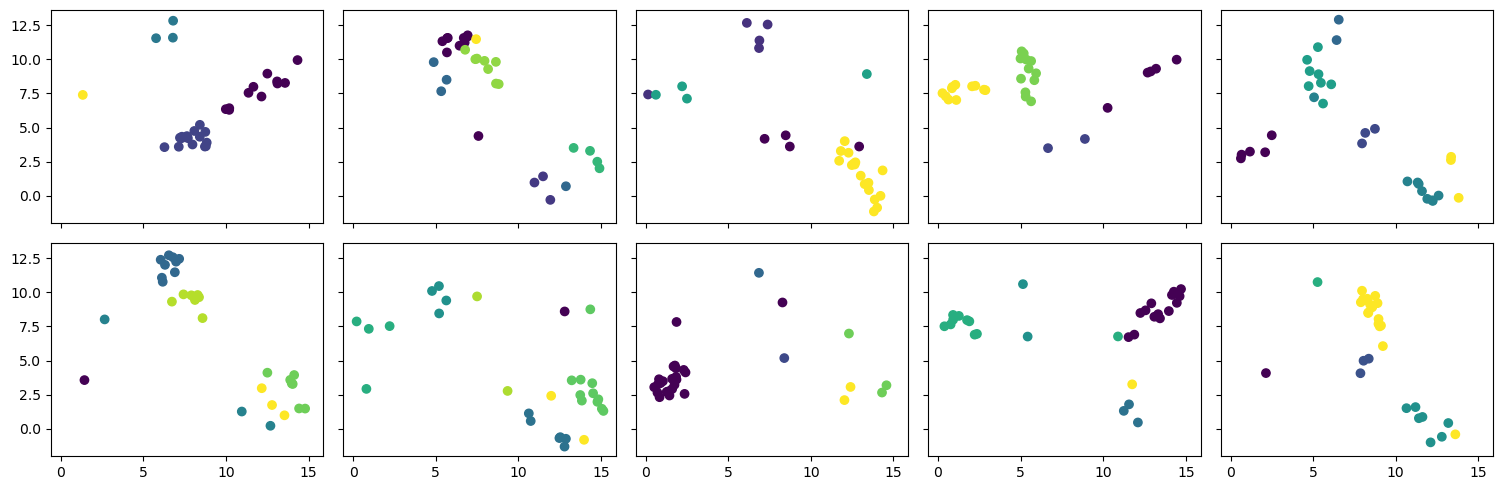

In [97]:
# Create the figure with 1 row and 3 columns
fig, axs = plt.subplots(2, 5, sharex=True, sharey=True, figsize=(15, 5))

# Loop through subplots and plot data
for i in range(5):
    X1, X2 = client_data[i][:,0], client_data[i][:,1]    
    axs[0, i].scatter(X1, X2, c=client_labels[i])
for i in range(5):
    X1, X2 = client_data[i+5][:,0], client_data[i+5][:,1]    
    axs[1, i].scatter(X1, X2, c=client_labels[i+5])

plt.tight_layout()
plt.show()

In [12]:
import os
import json
import pandas as pd

path_to_json = "outputs/means_shift/distrGTVMinKL/"

json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]
df_list = []
for f in json_files:
    with open(path_to_json+f) as json_data:
        data = json.load(json_data)
        json_data.close()

        rows = []
        rows.append({
            'D': data['config']['D'],
            'N': data['config']['N'],
            'shift_scale': data['config']['shift_scale'],
            'NMI': data['NMI'],
            'AMI': data['AMI']
        })

    df_list.append(pd.DataFrame(rows))

df = pd.concat(df_list, ignore_index=True)

In [13]:
df

,D,N,shift_scale,NMI,AMI
0,5,25,1.0,1.000000,1.000000
1,2,25,10.0,0.950900,0.950810
2,5,50,10.0,1.000000,1.000000
3,2,100,10.0,0.958858,0.958782
4,2,10,1.0,0.733277,0.732792
...,...,...,...,...,...
139,10,100,1.0,1.000000,1.000000
140,10,50,1.0,1.000000,1.000000
141,5,50,100.0,1.000000,1.000000
142,2,25,100.0,1.000000,1.000000


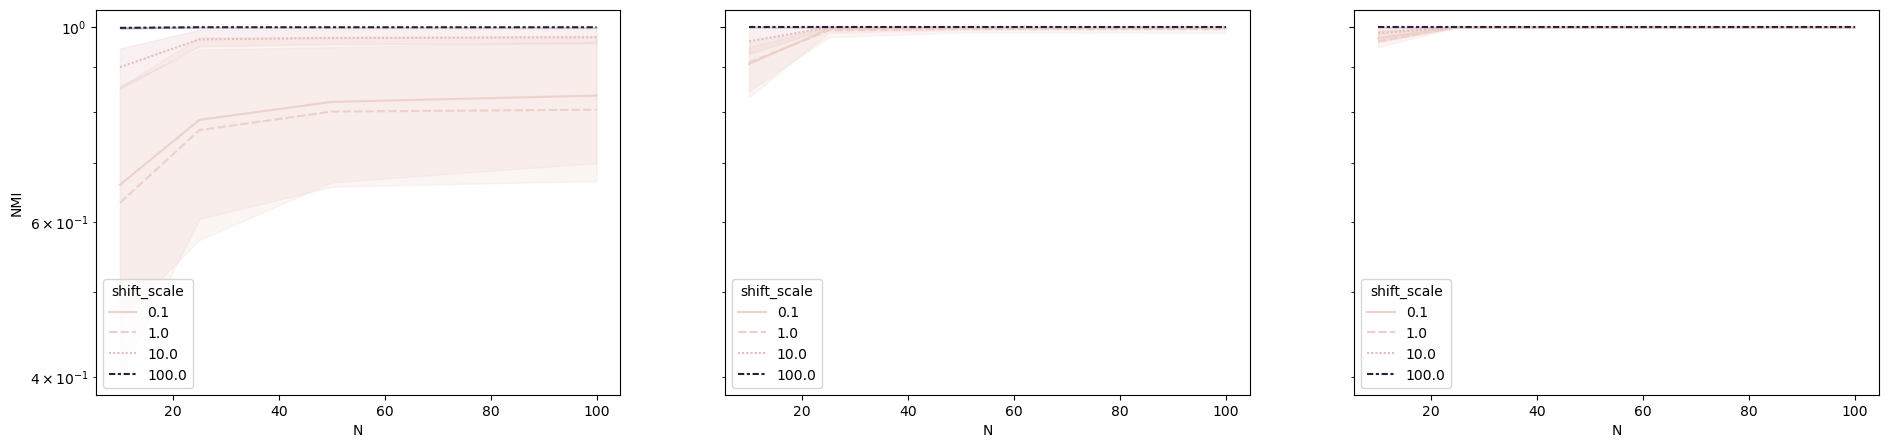

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

D_list = [2, 5, 10]

fig, axes = plt.subplots(1, 3, figsize=(23, 5), sharey=True)

for i in range(len(D_list)):
    data = df[df['D'] == D_list[i]]
    # sns.lineplot(data = df_final, ax = axes[i], x = each, y = 'TransformedWage', ci = None, color = 'g')
    axes[i].set(yscale="log")
    sns.lineplot(data=data, ax = axes[i], x="N", y="NMI", hue="shift_scale", style="shift_scale") 
plt.show()

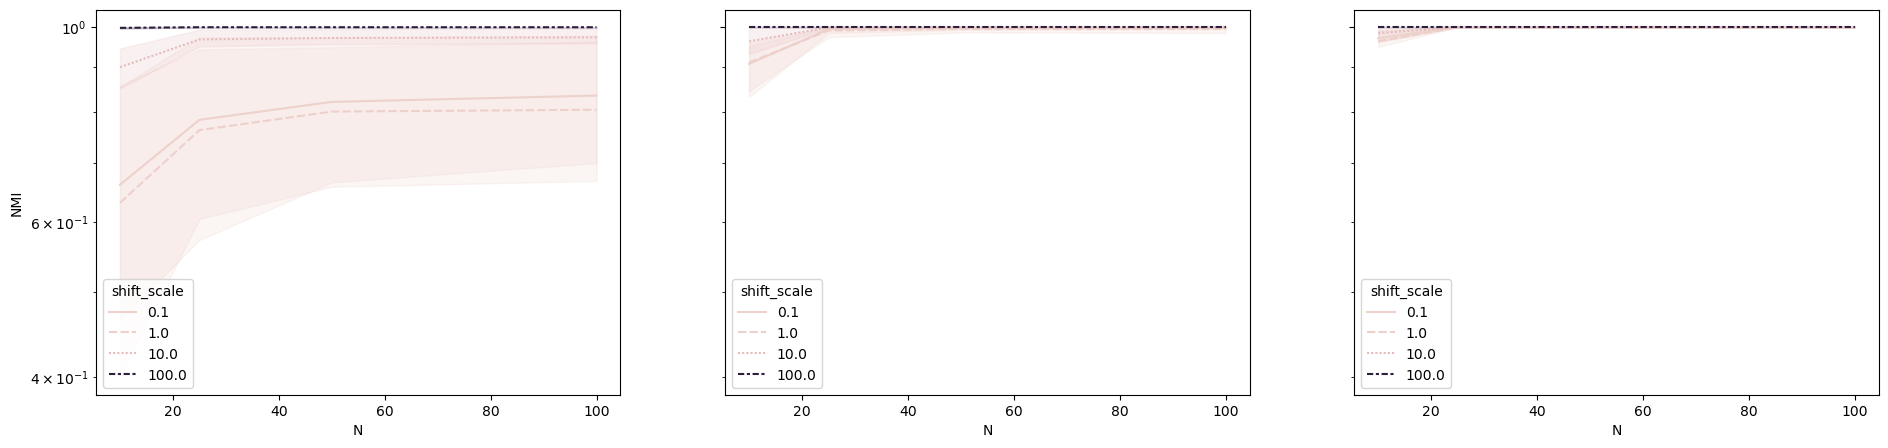

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

D_list = [2, 5, 10]

fig, axes = plt.subplots(1, 3, figsize=(23, 5), sharey=True)

for i in range(len(D_list)):
    data = df[df['D'] == D_list[i]]
    # sns.lineplot(data = df_final, ax = axes[i], x = each, y = 'TransformedWage', ci = None, color = 'g')
    axes[i].set(yscale="log")
    sns.lineplot(data=data, ax = axes[i], x="N", y="NMI", hue="shift_scale", style="shift_scale") 
plt.show()

In [25]:
means = np.random.randn(3, 3) * 5
shift_scale = 100
shifts = shift_scale * np.random.randn(10, 3, 3)
means_clients = means[None, :, :] + shifts


means_clients 

array([[[ -45.67893855,   32.34185817,   28.41256967],
        [  74.86553178, -108.18828852, -194.45359986],
        [-113.43965827,   82.39135447,   92.94004887]],

       [[ 155.78642764,   14.96214377,  148.11348187],
        [ 125.86874305,   38.14314512,   90.97427538],
        [ 100.70537994,   50.09341676,   91.53192748]],

       [[ -28.46171801, -123.4267191 , -159.32500495],
        [  -8.2208228 ,  -86.66648849, -103.73649793],
        [ 304.8947138 ,  -56.60613311, -115.69378849]],

       [[   4.02614464,    3.659515  ,   71.57305542],
        [  32.26805743,    5.47812953,   79.90570364],
        [ -18.5428867 ,  110.96691209,  -58.63175645]],

       [[ -33.99558044,  -34.87323237,  -48.32346572],
        [-176.31829377,  -46.97912551,  -89.49641145],
        [-114.80029143,  -31.7620487 ,  -77.20717504]],

       [[-104.11095363,  -82.92440521,   33.71905511],
        [ -70.62335448, -101.65350547,  -22.57188861],
        [  30.42277252,  -20.13006063,    8.15747785]],

In [55]:
var_scale = 100
var_scale * np.abs(1 + 0.5*np.random.randn(5))

array([101.89591315, 158.2860333 ,  98.82507686,  78.78000858,
       115.69415861])

In [63]:
var_scale = 1
log_var = np.random.randn(5) * 3.0  # controls diversity
var_scale * np.exp(log_var)

array([4.16850046, 0.04617028, 0.03535345, 7.91882952, 2.05343187])

In [95]:
var_scale = 10
if np.random.rand() < 0.5:
    # sharp cluster
    diag = var_scale * np.random.uniform(0.05, 0.5, size=5)
else:
    # wide cluster
    diag = var_scale * np.random.uniform(2, 5, size=5)
diag

array([22.01525335, 47.29956212, 30.81135338, 33.37569175, 33.89792922])